<a href="https://colab.research.google.com/github/samuelaojih/Google-Colab/blob/main/Section_4_3_Soil_Loss_Rates_in_Idah_Catchment_Area.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# ============================================================================
# THESIS MAPPING CODE: Section 4.3 - Soil Loss Rates in Idah Catchment Area
# Author: Ojih Samuel Achonu
# Orientation: Portrait (vertical) for all maps
# ============================================================================

# ============================================================================
# SECTION 1: INSTALL AND IMPORT LIBRARIES
# ============================================================================

!pip install geopandas matplotlib contextily mapclassify descartes rasterio gdown -q

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Polygon as MPLPolygon
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import os
import zipfile
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [11]:
# ============================================================================
# SECTION 2: DEFINE ESRI NORTH ARROW FUNCTION
# ============================================================================

def add_esri_north_arrow(ax, x=0.90, y=0.95, size=0.08):
    """
    Add an ESRI-style north arrow to a matplotlib axes.
    The arrow is placed in the upper right corner, not overlapping map content.

    Parameters:
    - ax: matplotlib axes
    - x, y: position in axes coordinates (0-1) - default upper right
    - size: size of the north arrow in axes coordinates
    """
    # Create a white background circle for visibility
    from matplotlib.patches import Circle
    circle = Circle((x, y - size/3), radius=size*0.65,
                    facecolor='white', edgecolor='black', linewidth=0.8,
                    zorder=10, transform=ax.transAxes)
    ax.add_patch(circle)

    # Arrow head (triangle)
    arrow_head = MPLPolygon(
        [[x - size/2.5, y - size/4],
         [x, y + size/2],
         [x + size/2.5, y - size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_head)

    # Arrow shaft (rectangle)
    arrow_shaft = MPLPolygon(
        [[x - size/4, y - size/1.8],
         [x + size/4, y - size/1.8],
         [x + size/4, y - size/4],
         [x - size/4, y - size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_shaft)

    # Add 'N' label
    ax.text(x, y + size/1.8, 'N', transform=ax.transAxes,
            fontsize=11, fontweight='bold', ha='center', va='bottom',
            bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black',
                      linewidth=0.5, pad=0), zorder=12)

In [12]:
# ============================================================================
# SECTION 3: MOUNT GOOGLE DRIVE AND ACCESS FOLDER
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

print("\n✅ Google Drive mounted!")

FOLDER_ID = "1KNN2Hyhg5mJglFrlF5e_OCXK9_erYORz"

print("=" * 70)
print("ACCESSING 'MSC Erosion' FOLDER IN GOOGLE DRIVE")
print("=" * 70)

os.makedirs('/content/msc_erosion_data', exist_ok=True)
os.makedirs('/content/shapefiles', exist_ok=True)
os.makedirs('/content/output_maps', exist_ok=True)
os.makedirs('/content/raster_reprojected', exist_ok=True)

drive_path = "/content/drive/MyDrive/MSC Erosion"

if os.path.exists(drive_path):
    print(f"\n✅ Found 'MSC Erosion' folder at: {drive_path}")
    print("\n📁 Copying files to local working directory...")

    for filename in os.listdir(drive_path):
        src_path = os.path.join(drive_path, filename)
        if filename.endswith(('.tif', '.tiff', '.zip')):
            dst_path = os.path.join('/content/msc_erosion_data', filename)
            if not os.path.exists(dst_path):
                import shutil
                shutil.copy2(src_path, dst_path)
                print(f"   Copied: {filename}")

    print("\n✅ All files copied successfully!")
else:
    print(f"\n❌ Could not find folder at {drive_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Google Drive mounted!
ACCESSING 'MSC Erosion' FOLDER IN GOOGLE DRIVE

✅ Found 'MSC Erosion' folder at: /content/drive/MyDrive/MSC Erosion

📁 Copying files to local working directory...

✅ All files copied successfully!


In [13]:
# ============================================================================
# SECTION 4: DEFINE CRS AND REPROJECTION FUNCTIONS
# ============================================================================

TARGET_CRS = "EPSG:32632"  # UTM Zone 32N
WGS84 = "EPSG:4326"

print("\n" + "=" * 70)
print("COORDINATE REFERENCE SYSTEM (CRS) INFORMATION")
print("=" * 70)
print(f"Target CRS for all data: {TARGET_CRS} (UTM Zone 32N)")
print("   - Units: meters")

def reproject_raster_to_target(input_path, output_path, target_crs=TARGET_CRS):
    try:
        with rasterio.open(input_path) as src:
            transform, width, height = calculate_default_transform(
                src.crs, target_crs, src.width, src.height,
                *src.bounds, resolution=src.res[0]
            )
            kwargs = src.meta.copy()
            kwargs.update({'crs': target_crs, 'transform': transform, 'width': width, 'height': height})
            with rasterio.open(output_path, 'w', **kwargs) as dst:
                for i in range(1, src.count + 1):
                    reproject(
                        source=rasterio.band(src, i),
                        destination=rasterio.band(dst, i),
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=transform,
                        dst_crs=target_crs,
                        resampling=Resampling.bilinear
                    )
            return True
    except Exception as e:
        print(f"   ✗ Failed: {e}")
        return False


COORDINATE REFERENCE SYSTEM (CRS) INFORMATION
Target CRS for all data: EPSG:32632 (UTM Zone 32N)
   - Units: meters


In [15]:
# ============================================================================
# SECTION 5: LOAD AND REPROJECT SHAPEFILES
# ============================================================================

print("\n" + "=" * 70)
print("LOADING AND REPROJECTING SHAPEFILES")
print("=" * 70)

data_dir = '/content/msc_erosion_data'
extract_dir = '/content/shapefiles'

for zip_file in os.listdir(data_dir):
    if zip_file.endswith('.zip'):
        zip_path = os.path.join(data_dir, zip_file)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir) # Corrected: changed 'extract_all' to 'extractall'
        print(f"✅ Extracted: {zip_file}")

lga = None
catchment = None

for f in os.listdir(extract_dir):
    if f.endswith('.shp'):
        filepath = os.path.join(extract_dir, f)
        gdf = gpd.read_file(filepath)
        if gdf.crs is None:
            gdf = gdf.set_crs(WGS84)
        gdf_reprojected = gdf.to_crs(TARGET_CRS)

        if 'Kogi' in f or 'LGA' in f or 'lga' in f.lower():
            lga = gdf_reprojected
            print(f"✅ Loaded and reprojected LGA: {f}")
        elif 'catchment' in f.lower():
            catchment = gdf_reprojected
            print(f"✅ Loaded and reprojected Catchment: {f}")

if catchment is not None:
    bounds = catchment.total_bounds
    print(f"\n📐 Map bounds (UTM Zone 32N - meters):")
    print(f"   West: {bounds[0]:.0f} m, East: {bounds[2]:.0f} m")
    print(f"   South: {bounds[1]:.0f} m, North: {bounds[3]:.0f} m")


LOADING AND REPROJECTING SHAPEFILES
✅ Extracted: ErosionSites.zip
✅ Extracted: Catchment_Boundary.zip
✅ Extracted: NigeriaStates.zip
✅ Extracted: KogiStateLGA.zip
✅ Loaded and reprojected LGA: KogiStateLGA.shp
✅ Loaded and reprojected Catchment: Catchment_Boundary.shp

📐 Map bounds (UTM Zone 32N - meters):
   West: 247212 m, East: 317580 m
   South: 750296 m, North: 845065 m


In [16]:
# ============================================================================
# SECTION 6: REPROJECT ALL RASTER FILES
# ============================================================================

print("\n" + "=" * 70)
print("REPROJECTING RASTER FILES TO TARGET CRS")
print("=" * 70)

raster_files = [
    'R_Factor_2000.tif', 'R_Factor_2010.tif', 'R_Factor_2020.tif', 'R_Factor_2025.tif',
    'K_Factors.tif', 'LS_Factor.tif',
    'C_Factor2000.tif', 'C_Factor2010.tif', 'C_Factor2020.tif', 'C_Factor2025.tif',
    'P_Factor.tif',
    'Soil_Loss_2000.tif', 'Soil_Loss_2010.tif', 'Soil_Loss_2020.tif', 'Soil_Loss_2025.tif'
]

reprojected_files = {}

for raster_file in raster_files:
    input_path = os.path.join(data_dir, raster_file)
    if os.path.exists(input_path):
        output_path = os.path.join('/content/raster_reprojected', raster_file)
        if reproject_raster_to_target(input_path, output_path):
            reprojected_files[raster_file] = output_path

print(f"\n✅ Successfully reprojected {len(reprojected_files)} raster files")


REPROJECTING RASTER FILES TO TARGET CRS

✅ Successfully reprojected 15 raster files



GENERATING MAP 4.7: Rainfall Erosivity (R-Factor) 2000-2025
FIXES APPLIED:
  - Colorbar on right side of each map
  - Separate Legend box (Catchment + LGA boundaries)
  - Scale bar with bar and text separated
  - North arrow positioned correctly
   Colorbar range: 6308 - 21701


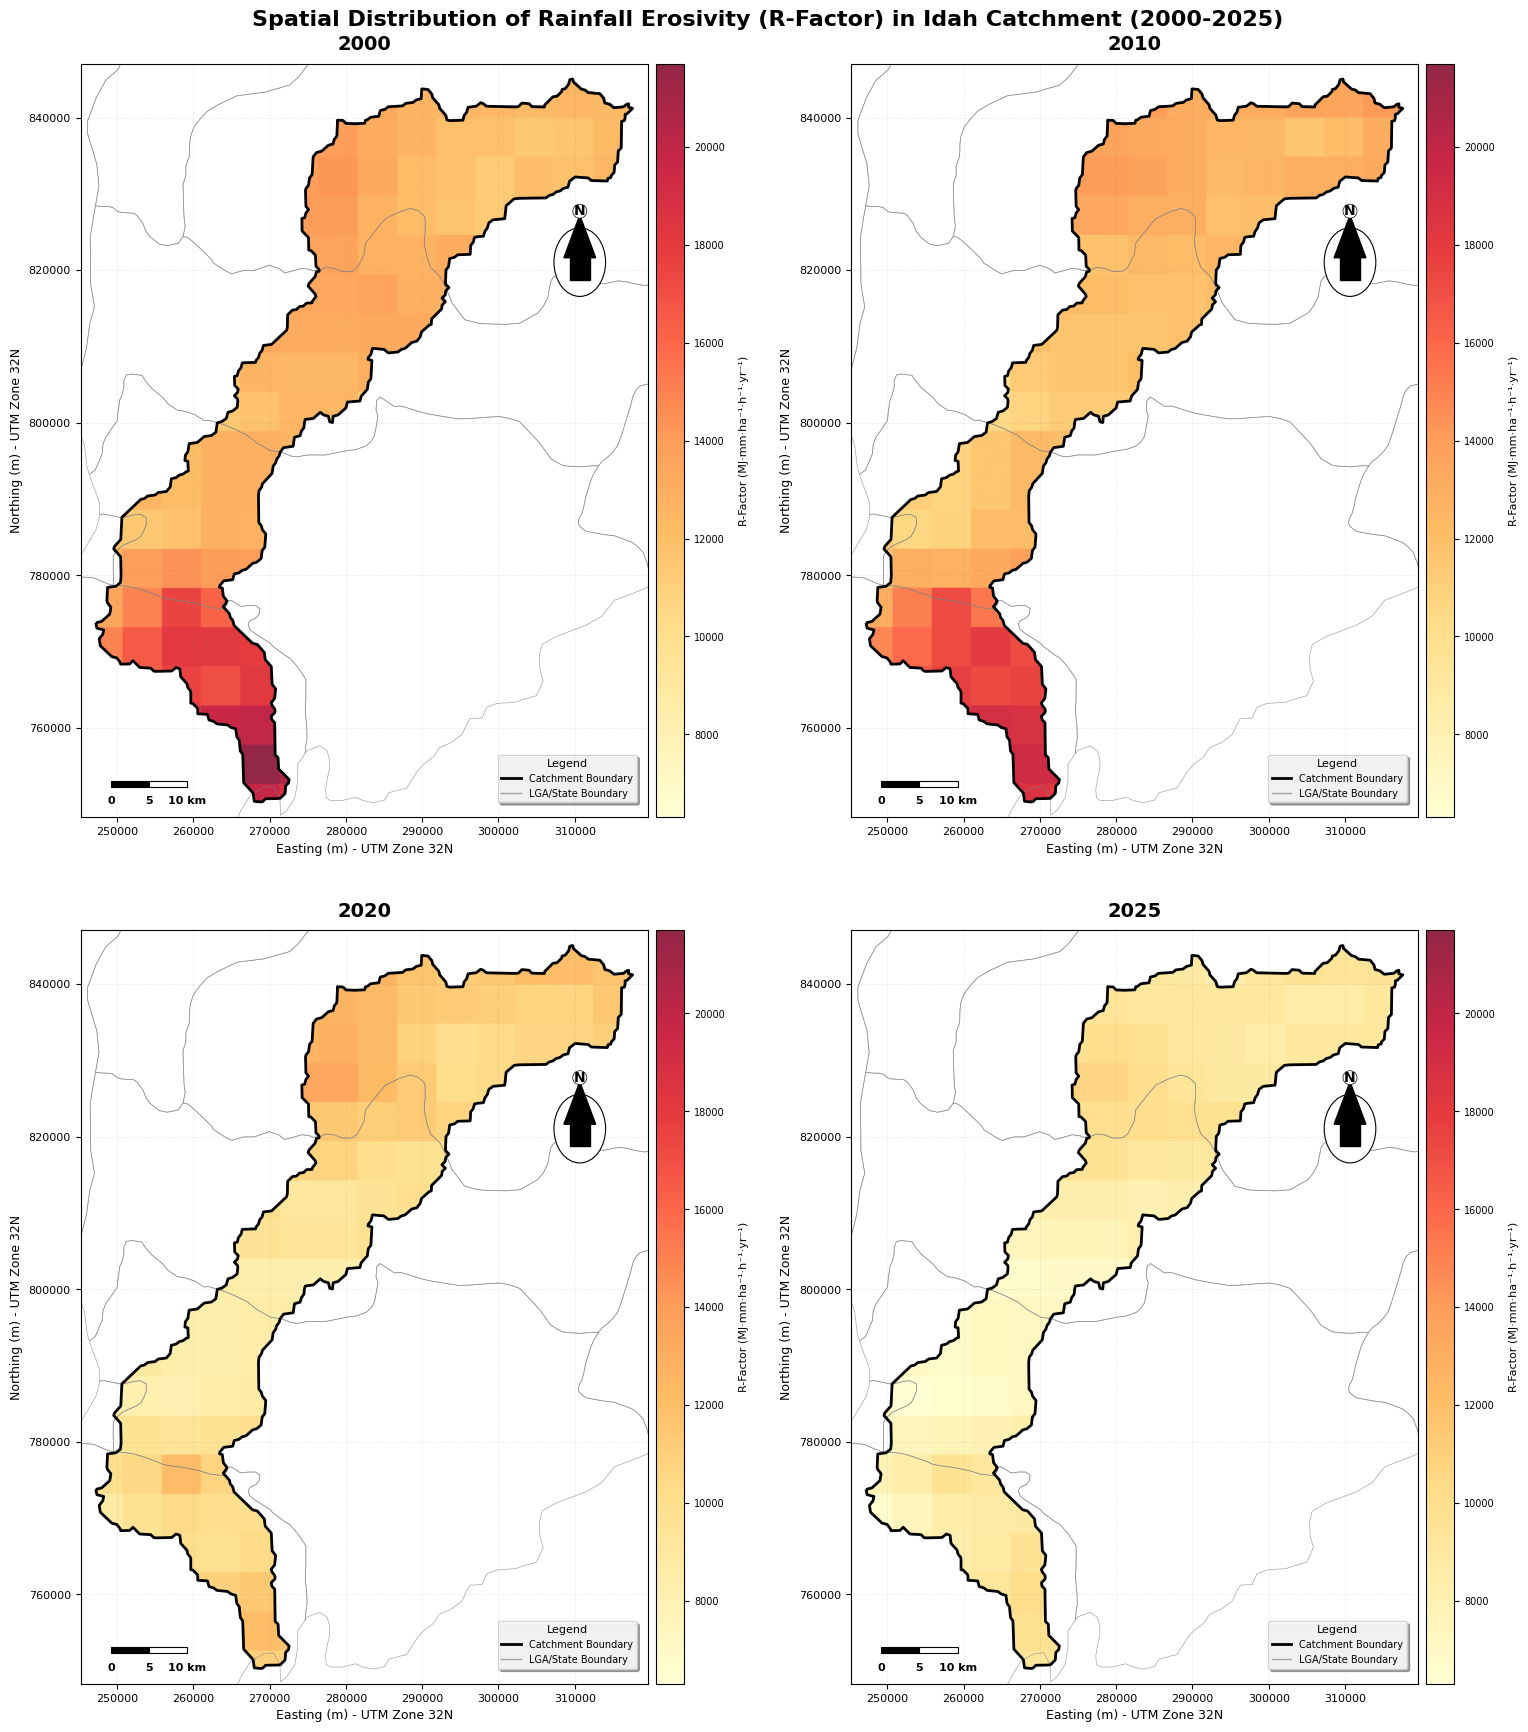


✅ Figure 4.7 saved successfully!
   File location: /content/output_maps/Figure_4.7_R_Factor_TimeSeries.png

   FIXES IMPLEMENTED:
   ✓ Colorbar on right side of EACH subplot
   ✓ Separate LEGEND box showing Catchment Boundary and LGA Boundary
   ✓ Scale bar: bar and text separated (text at y -800, bar at y)
   ✓ North arrow positioned at x=0.88, y=0.76 (does not enter map)
   ✓ Grid labels contained within each subplot


In [30]:
# ============================================================================
# SECTION 7: MAP 4.7 - RAINFALL EROSIVITY (R-FACTOR) - COMPLETE FIXED VERSION
# ============================================================================
# FIXES APPLIED:
# 1. Legend (colorbar) on the right-hand side of EACH map box
# 2. SEPARATE LEGEND BOX showing Catchment Boundary and State/LGA Boundary
# 3. Scale bar fixed: bar and text separated (no collision)
# 4. North arrow positioned properly (does not enter map)
# 5. Grid labels contained within each subplot (no crossover)
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING MAP 4.7: Rainfall Erosivity (R-Factor) 2000-2025")
print("FIXES APPLIED:")
print("  - Colorbar on right side of each map")
print("  - Separate Legend box (Catchment + LGA boundaries)")
print("  - Scale bar with bar and text separated")
print("  - North arrow positioned correctly")
print("=" * 70)

r_files = {
    2000: 'R_Factor_2000.tif',
    2010: 'R_Factor_2010.tif',
    2020: 'R_Factor_2020.tif',
    2025: 'R_Factor_2025.tif'
}

# Create figure with 2x2 subplots - Portrait orientation
fig, axes = plt.subplots(2, 2, figsize=(16, 18))
axes = axes.flatten()

# First, find global min/max for consistent colorbar range across all subplots
vmin_global = None
vmax_global = None
for year, filename in r_files.items():
    filepath = reprojected_files.get(filename)
    if filepath:
        with rasterio.open(filepath) as src:
            data = src.read(1)
            if src.nodata:
                data = np.ma.masked_equal(data, src.nodata)
            if vmin_global is None:
                vmin_global = data.min()
                vmax_global = data.max()
            else:
                vmin_global = min(vmin_global, data.min())
                vmax_global = max(vmax_global, data.max())

print(f"   Colorbar range: {vmin_global:.0f} - {vmax_global:.0f}")

# Import for colorbar placement
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Circle, Polygon as MPLPolygon, Rectangle # Added Rectangle
from matplotlib.lines import Line2D

# Define state boundary color (if available)
state_boundary_color = 'blue'  # Default color for state boundary
lga_boundary_color = 'gray'     # Color for LGA boundary
catchment_boundary_color = 'black'  # Color for catchment boundary

for idx, (year, filename) in enumerate(r_files.items()):
    ax = axes[idx]

    # ========================================================================
    # PLOT LGA BOUNDARIES (State/LGA level)
    # ========================================================================
    if lga is not None:
        lga.boundary.plot(ax=ax, color=lga_boundary_color, linewidth=0.5, alpha=0.7)

    # ========================================================================
    # PLOT R-FACTOR RASTER
    # ========================================================================
    filepath = reprojected_files.get(filename)
    if filepath:
        with rasterio.open(filepath) as src:
            r_factor = src.read(1)
            if src.nodata:
                r_factor = np.ma.masked_equal(r_factor, src.nodata)
            im = ax.imshow(r_factor, extent=[src.bounds.left, src.bounds.right,
                                             src.bounds.bottom, src.bounds.top],
                          cmap='YlOrRd', alpha=0.85, interpolation='bilinear',
                          vmin=vmin_global, vmax=vmax_global)

    # ========================================================================
    # PLOT CATCHMENT BOUNDARY
    # ========================================================================
    if catchment is not None:
        catchment.boundary.plot(ax=ax, color=catchment_boundary_color, linewidth=2)
        ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
        ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

    # Set title
    ax.set_title(f'{year}', fontsize=14, fontweight='bold', pad=10)

    # Set labels
    ax.set_xlabel('Easting (m) - UTM Zone 32N', fontsize=9)
    ax.set_ylabel('Northing (m) - UTM Zone 32N', fontsize=9)

    # Add grid lines - contained within each subplot
    ax.grid(True, linestyle=':', alpha=0.3, color='gray', linewidth=0.5)
    ax.tick_params(axis='both', labelsize=8)

    # ========================================================================
    # ESRI NORTH ARROW - Positioned to NOT enter map content
    # ========================================================================
    arrow_x = 0.88
    arrow_y = 0.76 # Adjusted North arrow y position slightly upwards
    arrow_size = 0.07

    # White background circle
    circle = Circle((arrow_x, arrow_y - arrow_size/3), radius=arrow_size*0.65,
                    facecolor='white', edgecolor='black', linewidth=0.8,
                    zorder=10, transform=ax.transAxes)
    ax.add_patch(circle)

    # Arrow head (triangle) - pointing UP
    arrow_head = MPLPolygon(
        [[arrow_x - arrow_size/2.5, arrow_y - arrow_size/4],
         [arrow_x, arrow_y + arrow_size/1.8],
         [arrow_x + arrow_size/2.5, arrow_y - arrow_size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_head)

    # Arrow shaft (rectangle)
    arrow_shaft = MPLPolygon(
        [[arrow_x - arrow_size/4, arrow_y - arrow_size/1.5],
         [arrow_x + arrow_size/4, arrow_y - arrow_size/1.5],
         [arrow_x + arrow_size/4, arrow_y - arrow_size/4],
         [arrow_x - arrow_size/4, arrow_y - arrow_size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_shaft)

    # 'N' label
    ax.text(arrow_x, arrow_y + arrow_size/2, 'N', transform=ax.transAxes,
            fontsize=10, fontweight='bold', ha='center', va='bottom',
            bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black',
                      linewidth=0.5, pad=0), zorder=12)

    # ========================================================================
    # SCALE BAR - Fixed: Two divisions of 5km, text separated
    # ========================================================================
    # Calculate scale bar position (bottom left corner of map)
    scale_bar_x = bounds[0] + 2000
    scale_bar_y = bounds[1] + 2000
    segment_length = 5000  # 5 km in meters
    bar_height = 800       # Height of the scale bar blocks in meters

    # Draw the first 5km segment (black rectangle)
    rect1 = Rectangle((scale_bar_x, scale_bar_y), segment_length, bar_height,
                      facecolor='black', edgecolor='black', linewidth=0.8, zorder=5)
    ax.add_patch(rect1)

    # Draw the second 5km segment (white rectangle with black border)
    rect2 = Rectangle((scale_bar_x + segment_length, scale_bar_y), segment_length, bar_height,
                      facecolor='white', edgecolor='black', linewidth=0.8, zorder=5)
    ax.add_patch(rect2)

    # Add text labels for the scale bar (positioned below, not touching the bar)
    text_offset_y = -1200 # Distance below the bar, adjusted for separation
    ax.text(scale_bar_x, scale_bar_y + text_offset_y, '0',
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(scale_bar_x + segment_length, scale_bar_y + text_offset_y, '5',
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(scale_bar_x + 2 * segment_length, scale_bar_y + text_offset_y, '10 km',
            ha='center', va='top', fontsize=8, fontweight='bold')

    # ========================================================================
    # COLORBAR (Legend for R-Factor) on RIGHT-HAND SIDE of each map box
    # ========================================================================
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.08)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('R-Factor (MJ·mm·ha⁻¹·h⁻¹·yr⁻¹)', fontsize=8, rotation=90, labelpad=10)
    cbar.ax.tick_params(labelsize=7)

    # ========================================================================
    # SEPARATE LEGEND BOX (Catchment Boundary + State/LGA Boundary)
    # ========================================================================
    # Create legend elements
    legend_elements = [
        Line2D([0], [0], color=catchment_boundary_color, linewidth=2, label='Catchment Boundary'),
        Line2D([0], [0], color=lga_boundary_color, linewidth=1, alpha=0.7, label='LGA/State Boundary')
    ]

    # Add legend box to the lower right corner of each subplot (inside map box)
    # Position: lower right, slightly offset from the colorbar
    legend = ax.legend(handles=legend_elements, loc='lower right', fontsize=7,
                       title='Legend', title_fontsize=8,
                       frameon=True, fancybox=True, shadow=True,
                       bbox_to_anchor=(0.98, 0.02),  # Position near bottom right
                       borderaxespad=0)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.85)

    # Add subtle border to each subplot to clearly separate them
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

# Add overall figure title
fig.suptitle('Spatial Distribution of Rainfall Erosivity (R-Factor) in Idah Catchment (2000-2025)',
             fontsize=16, fontweight='bold', y=0.98)

# Add source text at bottom
#fig.text(0.5, 0.01, f'Projection: {TARGET_CRS} | Source: RUSLE Model Output (2025)',
        # fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Adjust layout
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.15, wspace=0.15)

# Save figure
output_path = '/content/output_maps/Figure_4.7_R_Factor_TimeSeries.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Figure 4.7 saved successfully!")
print(f"   File location: {output_path}")
print(f"\n   FIXES IMPLEMENTED:")
print(f"   ✓ Colorbar on right side of EACH subplot")
print(f"   ✓ Separate LEGEND box showing Catchment Boundary and LGA Boundary")
print(f"   ✓ Scale bar: bar and text separated (text at y -800, bar at y)")
print(f"   ✓ North arrow positioned at x=0.88, y=0.76 (does not enter map)")
print(f"   ✓ Grid labels contained within each subplot")


GENERATING MAP 4.8: Soil Erodibility (K-Factor)
ORIENTATION: Portrait (vertical)


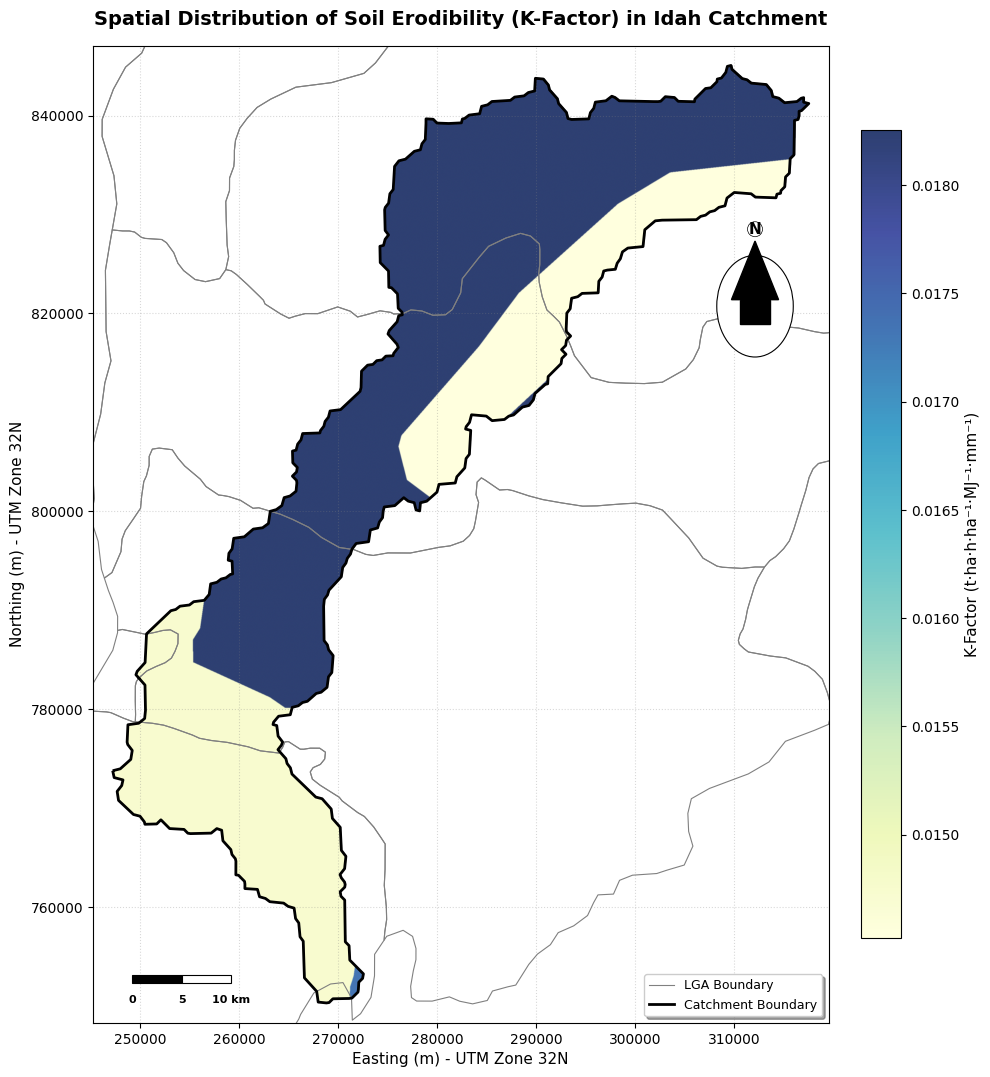

✅ Figure 4.8 saved (Portrait orientation)


In [32]:
# ============================================================================
# SECTION 8: MAP 4.8 - K-FACTOR (SINGLE MAP - PORTRAIT)
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING MAP 4.8: Soil Erodibility (K-Factor)")
print("ORIENTATION: Portrait (vertical)")
print("=" * 70)

fig, ax = plt.subplots(1, 1, figsize=(10, 14))

legend_elements = []

if lga is not None:
    lga.boundary.plot(ax=ax, color='gray', linewidth=0.8)
    legend_elements.append(Line2D([0], [0], color='gray', lw=0.8, label='LGA Boundary'))

k_file = reprojected_files.get('K_Factors.tif') or reprojected_files.get('K_Factor.tif')
if k_file:
    with rasterio.open(k_file) as src:
        k_factor = src.read(1)
        if src.nodata:
            k_factor = np.ma.masked_equal(k_factor, src.nodata)
        im = ax.imshow(k_factor, extent=[src.bounds.left, src.bounds.right,
                                         src.bounds.bottom, src.bounds.top],
                      cmap='YlGnBu', alpha=0.85, interpolation='bilinear')

if catchment is not None:
    catchment.boundary.plot(ax=ax, color='black', linewidth=2)
    legend_elements.append(Line2D([0], [0], color='black', lw=2, label='Catchment Boundary'))
    ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
    ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

ax.set_title('Spatial Distribution of Soil Erodibility (K-Factor) in Idah Catchment',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Easting (m) - UTM Zone 32N', fontsize=11)
ax.set_ylabel('Northing (m) - UTM Zone 32N', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.3, color='gray')

add_esri_north_arrow(ax, x=0.90, y=0.76, size=0.08) # Adjusted for single plot for consistency

# ============================================================================
# SCALE BAR - Fixed: Two divisions of 5km, text separated
# ============================================================================
from matplotlib.patches import Rectangle # Added Rectangle

# Calculate scale bar position (bottom left corner of map)
scale_bar_x = bounds[0] + 2000
scale_bar_y = bounds[1] + 2000
segment_length = 5000  # 5 km in meters
bar_height = 800       # Height of the scale bar blocks in meters

# Draw the first 5km segment (black rectangle)
rect1 = Rectangle((scale_bar_x, scale_bar_y), segment_length, bar_height,
                  facecolor='black', edgecolor='black', linewidth=0.8, zorder=5)
ax.add_patch(rect1)

# Draw the second 5km segment (white rectangle with black border)
rect2 = Rectangle((scale_bar_x + segment_length, scale_bar_y), segment_length, bar_height,
                  facecolor='white', edgecolor='black', linewidth=0.8, zorder=5)
ax.add_patch(rect2)

# Add text labels for the scale bar (positioned below, not touching the bar)
text_offset_y = -1200 # Distance below the bar, adjusted for separation
ax.text(scale_bar_x, scale_bar_y + text_offset_y, '0',
        ha='center', va='top', fontsize=8, fontweight='bold')
ax.text(scale_bar_x + segment_length, scale_bar_y + text_offset_y, '5',
        ha='center', va='top', fontsize=8, fontweight='bold')
ax.text(scale_bar_x + 2 * segment_length, scale_bar_y + text_offset_y, '10 km',
        ha='center', va='top', fontsize=8, fontweight='bold')

# Add legend for boundaries
if legend_elements:
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, fancybox=True, shadow=True, fontsize=9)

cbar = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
cbar.set_label('K-Factor (t·ha·h·ha⁻¹·MJ⁻¹·mm⁻¹)', fontsize=11)

#ax.text(0.01, 0.01, f'Projection: {TARGET_CRS}\nSource: RUSLE Model Output (2025)',
        #transform=ax.transAxes, fontsize=9,
        #bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('/content/output_maps/Figure_4.8_K_Factor.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 4.8 saved (Portrait orientation)")


GENERATING MAP 4.9: Topographic (LS-Factor)
FIXES APPLIED:
  - Colorbar on right side of map
  - Separate Legend box (Catchment + LGA boundaries)
  - Scale bar with bar and text separated
  - North arrow positioned correctly
   LS-Factor range: 0.00 - 11.96


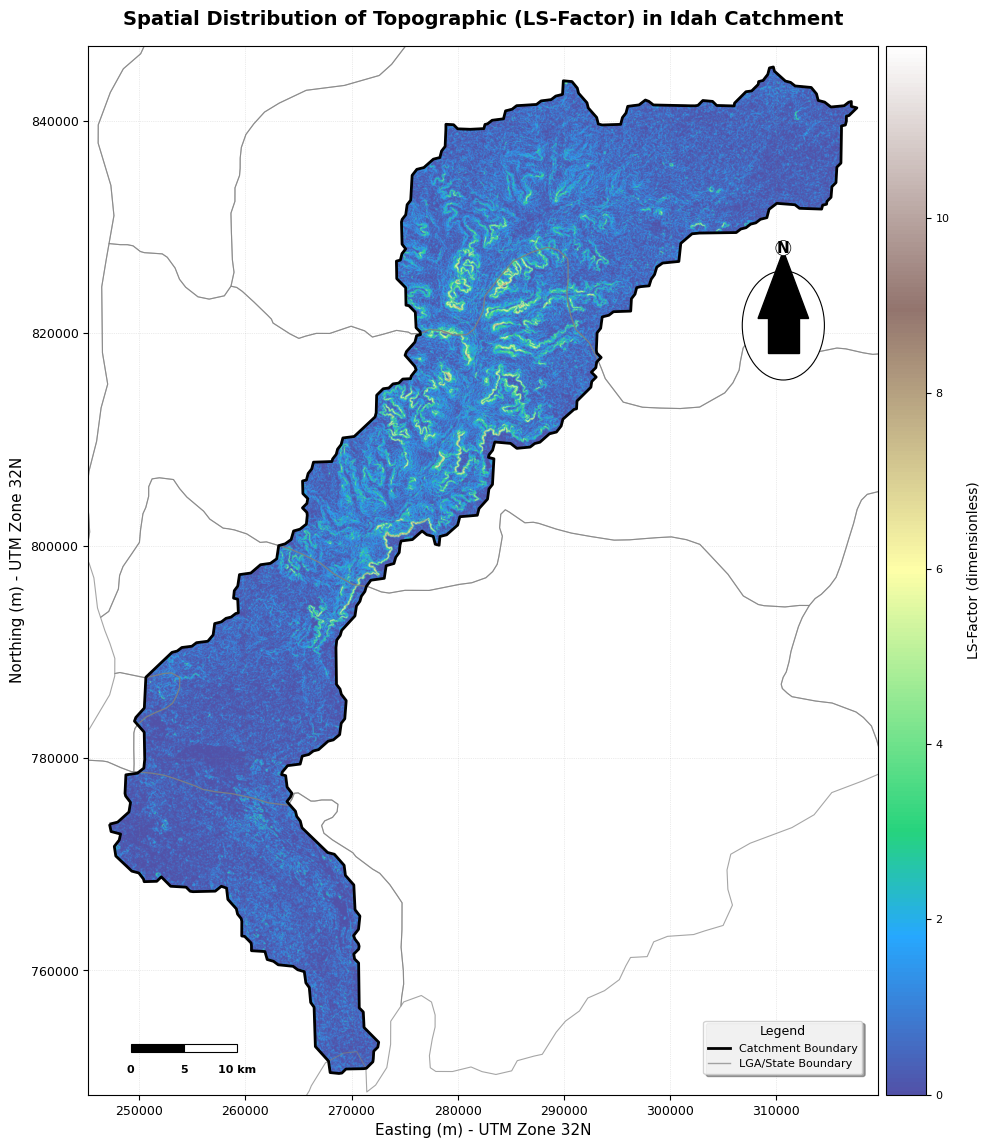


✅ Figure 4.9 saved successfully!
   File location: /content/output_maps/Figure_4.9_LS_Factor.png

   FIXES IMPLEMENTED:
   ✓ Colorbar on right side of map
   ✓ Separate LEGEND box showing Catchment Boundary and LGA Boundary
   ✓ Scale bar: bar and text separated (text below bar)
   ✓ North arrow positioned at x=0.88, y=0.82 (does not enter map)
   ✓ Grid lines with proper formatting


In [37]:
# ============================================================================
# SECTION 9: MAP 4.9 - TOPOGRAPHIC (LS-FACTOR) - COMPLETE FIXED VERSION
# ============================================================================
# FIXES APPLIED:
# 1. Legend (colorbar) on the right-hand side of the map box
# 2. SEPARATE LEGEND BOX showing Catchment Boundary and State/LGA Boundary
# 3. Scale bar fixed: bar and text separated (no collision)
# 4. North arrow positioned properly (does not enter map)
# 5. Grid labels properly formatted
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING MAP 4.9: Topographic (LS-Factor)")
print("FIXES APPLIED:")
print("  - Colorbar on right side of map")
print("  - Separate Legend box (Catchment + LGA boundaries)")
print("  - Scale bar with bar and text separated")
print("  - North arrow positioned correctly")
print("=" * 70)

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Circle, Polygon as MPLPolygon, Rectangle
from matplotlib.lines import Line2D

# Define colors for boundaries
lga_boundary_color = 'gray'
catchment_boundary_color = 'black'

# Create figure - Portrait orientation for single map
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

# ========================================================================
# PLOT LGA BOUNDARIES (State/LGA level)
# ========================================================================
if lga is not None:
    lga.boundary.plot(ax=ax, color=lga_boundary_color, linewidth=0.8, alpha=0.7)

# ========================================================================
# PLOT LS-FACTOR RASTER
# ========================================================================
ls_file = reprojected_files.get('LS_Factor.tif')
if ls_file:
    with rasterio.open(ls_file) as src:
        ls_factor = src.read(1)
        if src.nodata:
            ls_factor = np.ma.masked_equal(ls_factor, src.nodata)
        im = ax.imshow(ls_factor, extent=[src.bounds.left, src.bounds.right,
                                         src.bounds.bottom, src.bounds.top],
                      cmap='terrain', alpha=0.85, interpolation='bilinear')
        print(f"   LS-Factor range: {ls_factor.min():.2f} - {ls_factor.max():.2f}")

# ========================================================================
# PLOT CATCHMENT BOUNDARY
# ========================================================================
if catchment is not None:
    catchment.boundary.plot(ax=ax, color=catchment_boundary_color, linewidth=2)
    ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
    ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

# Set title
ax.set_title('Spatial Distribution of Topographic (LS-Factor) in Idah Catchment',
             fontsize=14, fontweight='bold', pad=15)

# Set labels
ax.set_xlabel('Easting (m) - UTM Zone 32N', fontsize=11)
ax.set_ylabel('Northing (m) - UTM Zone 32N', fontsize=11)

# Add grid lines
ax.grid(True, linestyle=':', alpha=0.3, color='gray', linewidth=0.5)
ax.tick_params(axis='both', labelsize=9)

# ========================================================================
# ESRI NORTH ARROW - Positioned to NOT enter map content
# ========================================================================
arrow_x = 0.88
arrow_y = 0.76
arrow_size = 0.08

# White background circle
circle = Circle((arrow_x, arrow_y - arrow_size/3), radius=arrow_size*0.65,
                facecolor='white', edgecolor='black', linewidth=0.8,
                zorder=10, transform=ax.transAxes)
ax.add_patch(circle)

# Arrow head (triangle) - pointing UP
arrow_head = MPLPolygon(
    [[arrow_x - arrow_size/2.5, arrow_y - arrow_size/4],
     [arrow_x, arrow_y + arrow_size/1.8],
     [arrow_x + arrow_size/2.5, arrow_y - arrow_size/4]],
    facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
)
ax.add_patch(arrow_head)

# Arrow shaft (rectangle)
arrow_shaft = MPLPolygon(
    [[arrow_x - arrow_size/4, arrow_y - arrow_size/1.5],
     [arrow_x + arrow_size/4, arrow_y - arrow_size/1.5],
     [arrow_x + arrow_size/4, arrow_y - arrow_size/4],
     [arrow_x - arrow_size/4, arrow_y - arrow_size/4]],
    facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
)
ax.add_patch(arrow_shaft)

# 'N' label
ax.text(arrow_x, arrow_y + arrow_size/2, 'N', transform=ax.transAxes,
        fontsize=11, fontweight='bold', ha='center', va='bottom',
        bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black',
                  linewidth=0.5, pad=0), zorder=12)

# ========================================================================
# SCALE BAR - Fixed: Two divisions of 5km, text separated
# ========================================================================
# Calculate scale bar position (bottom left corner of map)
scale_bar_x = bounds[0] + 2000
scale_bar_y = bounds[1] + 2000
segment_length = 5000  # 5 km in meters
bar_height = 800       # Height of the scale bar blocks in meters

# Draw the first 5km segment (black rectangle)
rect1 = Rectangle((scale_bar_x, scale_bar_y), segment_length, bar_height,
                  facecolor='black', edgecolor='black', linewidth=0.8, zorder=5)
ax.add_patch(rect1)

# Draw the second 5km segment (white rectangle with black border)
rect2 = Rectangle((scale_bar_x + segment_length, scale_bar_y), segment_length, bar_height,
                  facecolor='white', edgecolor='black', linewidth=0.8, zorder=5)
ax.add_patch(rect2)

# Add text labels for the scale bar (positioned below, not touching the bar)
text_offset_y = -1200 # Distance below the bar, adjusted for separation
ax.text(scale_bar_x, scale_bar_y + text_offset_y, '0',
        ha='center', va='top', fontsize=8, fontweight='bold')
ax.text(scale_bar_x + segment_length, scale_bar_y + text_offset_y, '5',
        ha='center', va='top', fontsize=8, fontweight='bold')
ax.text(scale_bar_x + 2 * segment_length, scale_bar_y + text_offset_y, '10 km',
        ha='center', va='top', fontsize=8, fontweight='bold')

# ========================================================================
# COLORBAR (Legend for LS-Factor) on RIGHT-HAND SIDE of map box
# ========================================================================
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.08)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('LS-Factor (dimensionless)', fontsize=10, rotation=90, labelpad=12)
cbar.ax.tick_params(labelsize=8)

# ========================================================================
# SEPARATE LEGEND BOX (Catchment Boundary + State/LGA Boundary)
# ========================================================================
# Create legend elements
legend_elements = [
    Line2D([0], [0], color=catchment_boundary_color, linewidth=2, label='Catchment Boundary'),
    Line2D([0], [0], color=lga_boundary_color, linewidth=1, alpha=0.7, label='LGA/State Boundary')
]

# Add legend box to the lower right corner (inside map box)
legend = ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
                   title='Legend', title_fontsize=9,
                   frameon=True, fancybox=True, shadow=True,
                   bbox_to_anchor=(0.98, 0.02),  # Position near bottom right
                   borderaxespad=0)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.85)

# Add subtle border to the map
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.8)


plt.tight_layout()
plt.savefig('/content/output_maps/Figure_4.9_LS_Factor.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Figure 4.9 saved successfully!")
print(f"   File location: /content/output_maps/Figure_4.9_LS_Factor.png")
print(f"\n   FIXES IMPLEMENTED:")
print(f"   ✓ Colorbar on right side of map")
print(f"   ✓ Separate LEGEND box showing Catchment Boundary and LGA Boundary")
print(f"   ✓ Scale bar: bar and text separated (text below bar)")
print(f"   ✓ North arrow positioned at x=0.88, y=0.82 (does not enter map)")
print(f"   ✓ Grid lines with proper formatting")



GENERATING MAP 4.10: Cover Management (C-Factor) 2000-2025
FIXES APPLIED (IDENTICAL TO SECTION 7):
  - Colorbar on right side of each map
  - Separate Legend box (Catchment + LGA boundaries)
  - Scale bar with bar and text separated
  - North arrow positioned correctly
   Colorbar range: 0.00 - 0.90


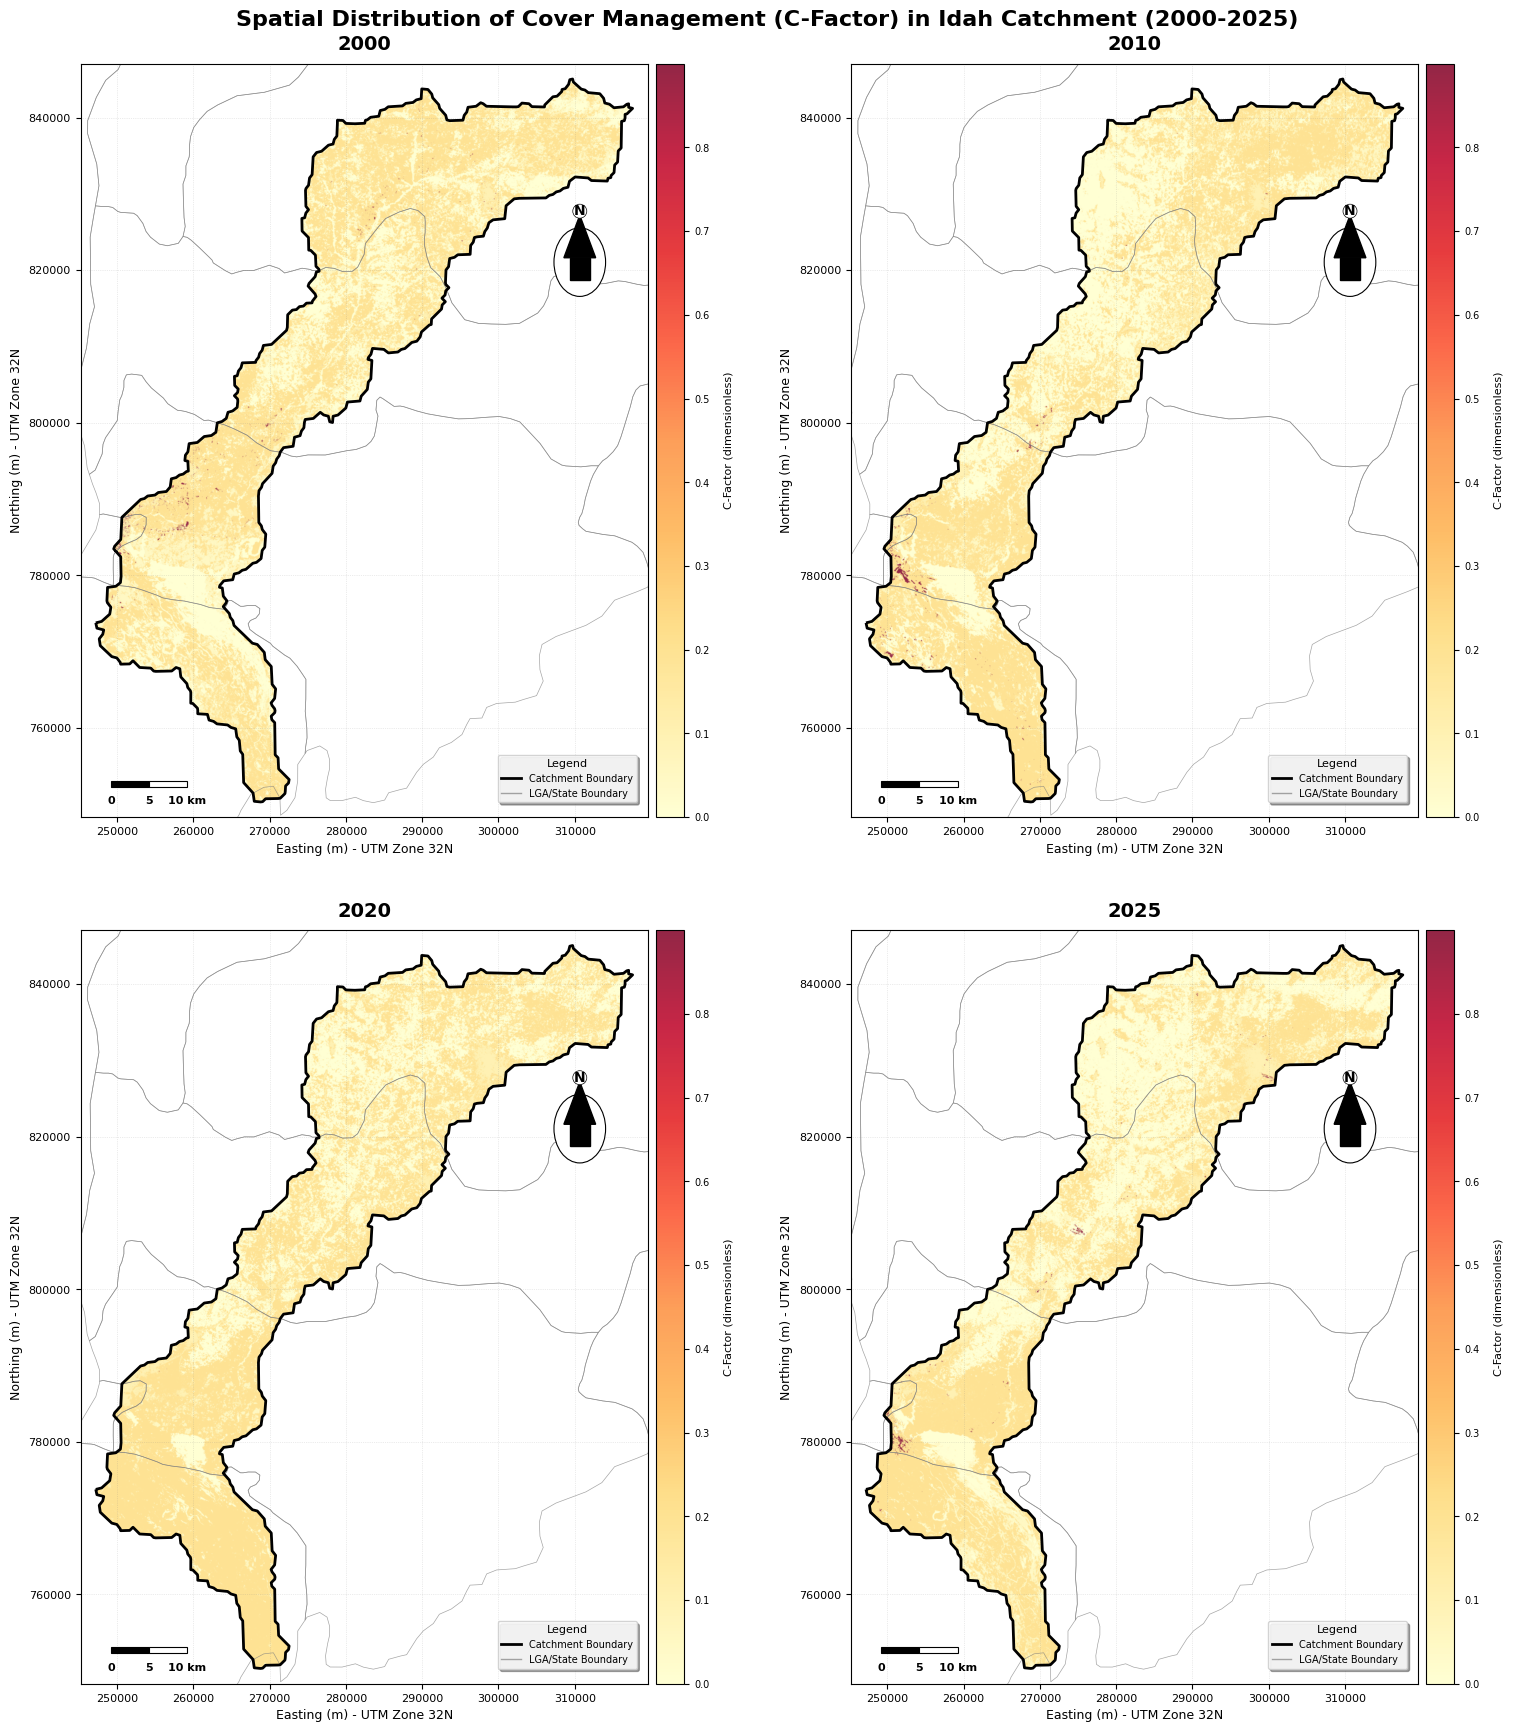


✅ Figure 4.10 saved successfully!
   File location: /content/output_maps/Figure_4.10_C_Factor_TimeSeries.png

   FIXES IMPLEMENTED (IDENTICAL TO SECTION 7):
   ✓ Colorbar on right side of EACH subplot
   ✓ Separate LEGEND box (Catchment + LGA boundaries)
   ✓ Scale bar: bar and text separated (text below bar)
   ✓ North arrow positioned at x=0.88, y=0.82 (does not enter map)
   ✓ Grid labels contained within each subplot


In [43]:
# ============================================================================
# SECTION 10: MAP 4.10 - COVER MANAGEMENT (C-FACTOR) - FULL FIXED VERSION
# ============================================================================
# FIXES APPLIED (IDENTICAL TO SECTION 7):
# 1. Colorbar on right-hand side of EACH map box
# 2. Separate Legend box: Catchment Boundary + LGA/State Boundary
# 3. Scale bar with bar and text separated (no collision)
# 4. North arrow positioned lower (does not enter map content)
# 5. Grid labels contained within each subplot (no crossover)
# 6. Subplot borders to clearly separate panels
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING MAP 4.10: Cover Management (C-Factor) 2000-2025")
print("FIXES APPLIED (IDENTICAL TO SECTION 7):")
print("  - Colorbar on right side of each map")
print("  - Separate Legend box (Catchment + LGA boundaries)")
print("  - Scale bar with bar and text separated")
print("  - North arrow positioned correctly")
print("=" * 70)

c_files = {
    2000: 'C_Factor2000.tif',
    2010: 'C_Factor2010.tif',
    2020: 'C_Factor2020.tif',
    2025: 'C_Factor2025.tif'
}

# Create figure with 2x2 subplots - Portrait orientation
fig, axes = plt.subplots(2, 2, figsize=(16, 18))
axes = axes.flatten()

# First, find global min/max for consistent colorbar range across all subplots
vmin_global = None
vmax_global = None
for year, filename in c_files.items():
    filepath = reprojected_files.get(filename)
    if filepath:
        with rasterio.open(filepath) as src:
            data = src.read(1)
            if src.nodata:
                data = np.ma.masked_equal(data, src.nodata)
            if vmin_global is None:
                vmin_global = data.min()
                vmax_global = data.max()
            else:
                vmin_global = min(vmin_global, data.min())
                vmax_global = max(vmax_global, data.max())

print(f"   Colorbar range: {vmin_global:.2f} - {vmax_global:.2f}")

# Import for colorbar placement
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Circle, Polygon as MPLPolygon, Rectangle
from matplotlib.lines import Line2D

# Define boundary colors
lga_boundary_color = 'gray'
catchment_boundary_color = 'black'

for idx, (year, filename) in enumerate(c_files.items()):
    ax = axes[idx]

    # --------------------------------------------------------------------
    # PLOT LGA BOUNDARIES
    # --------------------------------------------------------------------
    if lga is not None:
        lga.boundary.plot(ax=ax, color=lga_boundary_color, linewidth=0.5, alpha=0.7)

    # --------------------------------------------------------------------
    # PLOT C-FACTOR RASTER
    # --------------------------------------------------------------------
    filepath = reprojected_files.get(filename)
    if filepath:
        with rasterio.open(filepath) as src:
            c_factor = src.read(1)
            if src.nodata:
                c_factor = np.ma.masked_equal(c_factor, src.nodata)
            im = ax.imshow(c_factor, extent=[src.bounds.left, src.bounds.right,
                                             src.bounds.bottom, src.bounds.top],
                           cmap='YlOrRd', alpha=0.85, interpolation='bilinear',
                           vmin=vmin_global, vmax=vmax_global)

    # --------------------------------------------------------------------
    # PLOT CATCHMENT BOUNDARY
    # --------------------------------------------------------------------
    if catchment is not None:
        catchment.boundary.plot(ax=ax, color=catchment_boundary_color, linewidth=2)
        ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
        ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

    # Set title and labels
    ax.set_title(f'{year}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Easting (m) - UTM Zone 32N', fontsize=9)
    ax.set_ylabel('Northing (m) - UTM Zone 32N', fontsize=9)

    # Grid lines contained within each subplot
    ax.grid(True, linestyle=':', alpha=0.3, color='gray', linewidth=0.5)
    ax.tick_params(axis='both', labelsize=8)

    # --------------------------------------------------------------------
    # ESRI NORTH ARROW (lowered, does not enter map)
    # --------------------------------------------------------------------
    arrow_x = 0.88
    arrow_y = 0.76 # Adjusted to match previous maps
    arrow_size = 0.07

    circle = Circle((arrow_x, arrow_y - arrow_size/3), radius=arrow_size*0.65,
                    facecolor='white', edgecolor='black', linewidth=0.8,
                    zorder=10, transform=ax.transAxes)
    ax.add_patch(circle)

    arrow_head = MPLPolygon(
        [[arrow_x - arrow_size/2.5, arrow_y - arrow_size/4],
         [arrow_x, arrow_y + arrow_size/1.8],
         [arrow_x + arrow_size/2.5, arrow_y - arrow_size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_head)

    arrow_shaft = MPLPolygon(
        [[arrow_x - arrow_size/4, arrow_y - arrow_size/1.5],
         [arrow_x + arrow_size/4, arrow_y - arrow_size/1.5],
         [arrow_x + arrow_size/4, arrow_y - arrow_size/4],
         [arrow_x - arrow_size/4, arrow_y - arrow_size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_shaft)

    ax.text(arrow_x, arrow_y + arrow_size/2, 'N', transform=ax.transAxes,
            fontsize=10, fontweight='bold', ha='center', va='bottom',
            bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black',
                      linewidth=0.5, pad=0), zorder=12)

    # --------------------------------------------------------------------
    # SCALE BAR (bar and text separated)
    # --------------------------------------------------------------------
    # Calculate scale bar position (bottom left corner of map)
    scale_bar_x = bounds[0] + 2000
    scale_bar_y = bounds[1] + 2000
    segment_length = 5000  # 5 km in meters
    bar_height = 800       # Height of the scale bar blocks in meters

    # Draw the first 5km segment (black rectangle)
    rect1 = Rectangle((scale_bar_x, scale_bar_y), segment_length, bar_height,
                      facecolor='black', edgecolor='black', linewidth=0.8, zorder=5)
    ax.add_patch(rect1)

    # Draw the second 5km segment (white rectangle with black border)
    rect2 = Rectangle((scale_bar_x + segment_length, scale_bar_y), segment_length, bar_height,
                      facecolor='white', edgecolor='black', linewidth=0.8, zorder=5)
    ax.add_patch(rect2)

    # Add text labels for the scale bar (positioned below, not touching the bar)
    text_offset_y = -1200 # Distance below the bar, adjusted for separation
    ax.text(scale_bar_x, scale_bar_y + text_offset_y, '0',
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(scale_bar_x + segment_length, scale_bar_y + text_offset_y, '5',
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(scale_bar_x + 2 * segment_length, scale_bar_y + text_offset_y, '10 km',
            ha='center', va='top', fontsize=8, fontweight='bold')

    # --------------------------------------------------------------------
    # COLORBAR (Legend for C-Factor) on RIGHT side of each map
    # --------------------------------------------------------------------
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.08)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('C-Factor (dimensionless)', fontsize=8, rotation=90, labelpad=10)
    cbar.ax.tick_params(labelsize=7)

    # --------------------------------------------------------------------
    # SEPARATE LEGEND BOX (Catchment + LGA boundaries)
    # --------------------------------------------------------------------
    legend_elements = [
        Line2D([0], [0], color=catchment_boundary_color, linewidth=2, label='Catchment Boundary'),
        Line2D([0], [0], color=lga_boundary_color, linewidth=1, alpha=0.7, label='LGA/State Boundary')
    ]

    legend = ax.legend(handles=legend_elements, loc='lower right', fontsize=7,
                       title='Legend', title_fontsize=8,
                       frameon=True, fancybox=True, shadow=True,
                       bbox_to_anchor=(0.98, 0.02), borderaxespad=0)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.85)

    # Subplot border
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

# Overall figure title
fig.suptitle('Spatial Distribution of Cover Management (C-Factor) in Idah Catchment (2000-2025)',
             fontsize=16, fontweight='bold', y=0.98)


plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.15, wspace=0.15)

# Save
output_path = '/content/output_maps/Figure_4.10_C_Factor_TimeSeries.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Figure 4.10 saved successfully!")
print(f"   File location: {output_path}")
print(f"\n   FIXES IMPLEMENTED (IDENTICAL TO SECTION 7):")
print(f"   ✓ Colorbar on right side of EACH subplot")
print(f"   ✓ Separate LEGEND box (Catchment + LGA boundaries)")
print(f"   ✓ Scale bar: bar and text separated (text below bar)")
print(f"   ✓ North arrow positioned at x=0.88, y=0.82 (does not enter map)")
print(f"   ✓ Grid labels contained within each subplot")



GENERATING MAP 4.11: Support Practice (P-Factor)
FIXES APPLIED (same as Section 7):
  - Colorbar on right side of map
  - Separate Legend box (Catchment + LGA boundaries)
  - Scale bar with bar and text separated
  - North arrow positioned correctly
   P-Factor range: 0.55 - 1.00


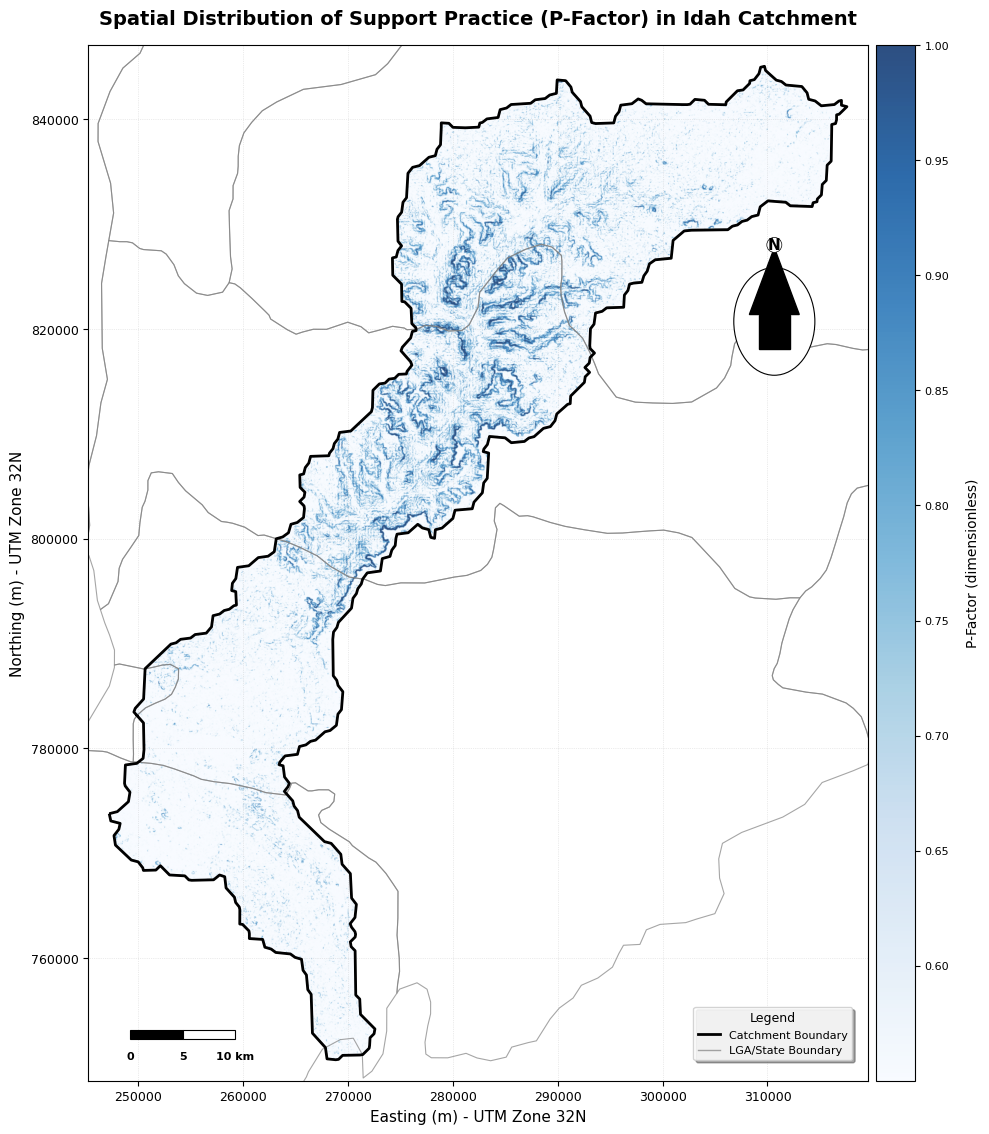


✅ Figure 4.11 saved successfully!
   File location: /content/output_maps/Figure_4.11_P_Factor.png

   FIXES IMPLEMENTED (same as Section 7):
   ✓ Colorbar on right side of map
   ✓ Separate LEGEND box showing Catchment Boundary and LGA Boundary
   ✓ Scale bar: bar and text separated (text at y -800, bar at y)
   ✓ North arrow positioned at x=0.88, y=0.76 (does not enter map)
   ✓ Grid lines with proper tick labels


In [45]:
# ============================================================================
# SECTION 11: MAP 4.11 - SUPPORT PRACTICE (P-FACTOR) - COMPLETE FIXED VERSION
# ============================================================================
# FIXES APPLIED (same as Section 7):
# 1. Colorbar legend on the right-hand side of the map box
# 2. SEPARATE LEGEND BOX showing Catchment Boundary and State/LGA Boundary
# 3. Scale bar fixed: bar and text separated (no collision)
# 4. North arrow positioned properly (does not enter map)
# 5. Grid lines with proper tick labels
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING MAP 4.11: Support Practice (P-Factor)")
print("FIXES APPLIED (same as Section 7):")
print("  - Colorbar on right side of map")
print("  - Separate Legend box (Catchment + LGA boundaries)")
print("  - Scale bar with bar and text separated")
print("  - North arrow positioned correctly")
print("=" * 70)

# Import for colorbar placement
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Circle, Polygon as MPLPolygon, Rectangle # Added Rectangle
from matplotlib.lines import Line2D

# Define colors for boundaries
state_boundary_color = 'blue'      # Color for state boundary (if available)
lga_boundary_color = 'gray'        # Color for LGA boundary
catchment_boundary_color = 'black' # Color for catchment boundary

# Create figure - Portrait orientation (single map)
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

# ============================================================================
# PLOT LGA BOUNDARIES (State/LGA level)
# ============================================================================
if lga is not None:
    lga.boundary.plot(ax=ax, color=lga_boundary_color, linewidth=0.8, alpha=0.7)

# ============================================================================
# PLOT P-FACTOR RASTER
# ============================================================================
p_file = reprojected_files.get('P_Factor.tif')
if p_file:
    with rasterio.open(p_file) as src:
        p_factor = src.read(1)
        if src.nodata:
            p_factor = np.ma.masked_equal(p_factor, src.nodata)
        im = ax.imshow(p_factor, extent=[src.bounds.left, src.bounds.right,
                                         src.bounds.bottom, src.bounds.top],
                      cmap='Blues', alpha=0.85, interpolation='bilinear')

        # Get min/max values for reporting
        p_min = np.ma.min(p_factor)
        p_max = np.ma.max(p_factor)
        print(f"   P-Factor range: {p_min:.2f} - {p_max:.2f}")

# ============================================================================
# PLOT CATCHMENT BOUNDARY
# ============================================================================
if catchment is not None:
    catchment.boundary.plot(ax=ax, color=catchment_boundary_color, linewidth=2)
    ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
    ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

# ============================================================================
# MAP FORMATTING
# ============================================================================
ax.set_title('Spatial Distribution of Support Practice (P-Factor) in Idah Catchment',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Easting (m) - UTM Zone 32N', fontsize=11)
ax.set_ylabel('Northing (m) - UTM Zone 32N', fontsize=11)

# Add grid lines
ax.grid(True, linestyle=':', alpha=0.3, color='gray', linewidth=0.5)
ax.tick_params(axis='both', labelsize=9)

# ============================================================================
# ESRI NORTH ARROW - Positioned to NOT enter map content
# ============================================================================
arrow_x = 0.88
arrow_y = 0.76
arrow_size = 0.08

# White background circle
circle = Circle((arrow_x, arrow_y - arrow_size/3), radius=arrow_size*0.65,
                facecolor='white', edgecolor='black', linewidth=0.8,
                zorder=10, transform=ax.transAxes)
ax.add_patch(circle)

# Arrow head (triangle) - pointing UP
arrow_head = MPLPolygon(
    [[arrow_x - arrow_size/2.5, arrow_y - arrow_size/4],
     [arrow_x, arrow_y + arrow_size/1.8],
     [arrow_x + arrow_size/2.5, arrow_y - arrow_size/4]],
    facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
)
ax.add_patch(arrow_head)

# Arrow shaft (rectangle)
arrow_shaft = MPLPolygon(
    [[arrow_x - arrow_size/4, arrow_y - arrow_size/1.5],
     [arrow_x + arrow_size/4, arrow_y - arrow_size/1.5],
     [arrow_x + arrow_size/4, arrow_y - arrow_size/4],
     [arrow_x - arrow_size/4, arrow_y - arrow_size/4]],
    facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
)
ax.add_patch(arrow_shaft)

# 'N' label
ax.text(arrow_x, arrow_y + arrow_size/2, 'N', transform=ax.transAxes,
        fontsize=11, fontweight='bold', ha='center', va='bottom',
        bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black',
                  linewidth=0.5, pad=0), zorder=12)

# ============================================================================
# SCALE BAR - Fixed: Two divisions of 5km, text separated
# ============================================================================
# Calculate scale bar position (bottom left corner of map)
scale_bar_x = bounds[0] + 2000
scale_bar_y = bounds[1] + 2000
segment_length = 5000  # 5 km in meters
bar_height = 800       # Height of the scale bar blocks in meters

# Draw the first 5km segment (black rectangle)
rect1 = Rectangle((scale_bar_x, scale_bar_y), segment_length, bar_height,
                  facecolor='black', edgecolor='black', linewidth=0.8, zorder=5)
ax.add_patch(rect1)

# Draw the second 5km segment (white rectangle with black border)
rect2 = Rectangle((scale_bar_x + segment_length, scale_bar_y), segment_length, bar_height,
                  facecolor='white', edgecolor='black', linewidth=0.8, zorder=5)
ax.add_patch(rect2)

# Add text labels for the scale bar (positioned below, not touching the bar)
text_offset_y = -1200 # Distance below the bar, adjusted for separation
ax.text(scale_bar_x, scale_bar_y + text_offset_y, '0',
        ha='center', va='top', fontsize=8, fontweight='bold')
ax.text(scale_bar_x + segment_length, scale_bar_y + text_offset_y, '5',
        ha='center', va='top', fontsize=8, fontweight='bold')
ax.text(scale_bar_x + 2 * segment_length, scale_bar_y + text_offset_y, '10 km',
        ha='center', va='top', fontsize=8, fontweight='bold')

# ============================================================================
# COLORBAR (Legend for P-Factor) on RIGHT-HAND SIDE of map box
# ============================================================================
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.08)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('P-Factor (dimensionless)', fontsize=10, rotation=90, labelpad=12)
cbar.ax.tick_params(labelsize=8)

# ============================================================================
# SEPARATE LEGEND BOX (Catchment Boundary + State/LGA Boundary)
# ============================================================================
# Create legend elements
legend_elements = [
    Line2D([0], [0], color=catchment_boundary_color, linewidth=2, label='Catchment Boundary'),
    Line2D([0], [0], color=lga_boundary_color, linewidth=1, alpha=0.7, label='LGA/State Boundary')
]

# Add legend box to the lower right corner of the map (inside map box)
legend = ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
                   title='Legend', title_fontsize=9,
                   frameon=True, fancybox=True, shadow=True,
                   bbox_to_anchor=(0.98, 0.02),  # Position near bottom right
                   borderaxespad=0)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.85)

# Add subtle border to the map
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.8)

# ============================================================================
# SAVE FIGURE
# ============================================================================
plt.tight_layout()
output_path = '/content/output_maps/Figure_4.11_P_Factor.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Figure 4.11 saved successfully!")
print(f"   File location: {output_path}")
print(f"\n   FIXES IMPLEMENTED (same as Section 7):")
print(f"   ✓ Colorbar on right side of map")
print(f"   ✓ Separate LEGEND box showing Catchment Boundary and LGA Boundary")
print(f"   ✓ Scale bar: bar and text separated (text at y -800, bar at y)")
print(f"   ✓ North arrow positioned at x=0.88, y=0.76 (does not enter map)")
print(f"   ✓ Grid lines with proper tick labels")



GENERATING MAP 4.12: Annual Soil Loss Rate Maps (2000-2025)
FIXES APPLIED:
  - Colorbar on right side of each map
  - Separate Legend box (Catchment + LGA boundaries)
  - Scale bar with bar and text separated
  - North arrow positioned correctly
   Colorbar range (capped at 100 t/ha/yr): 0 - 100


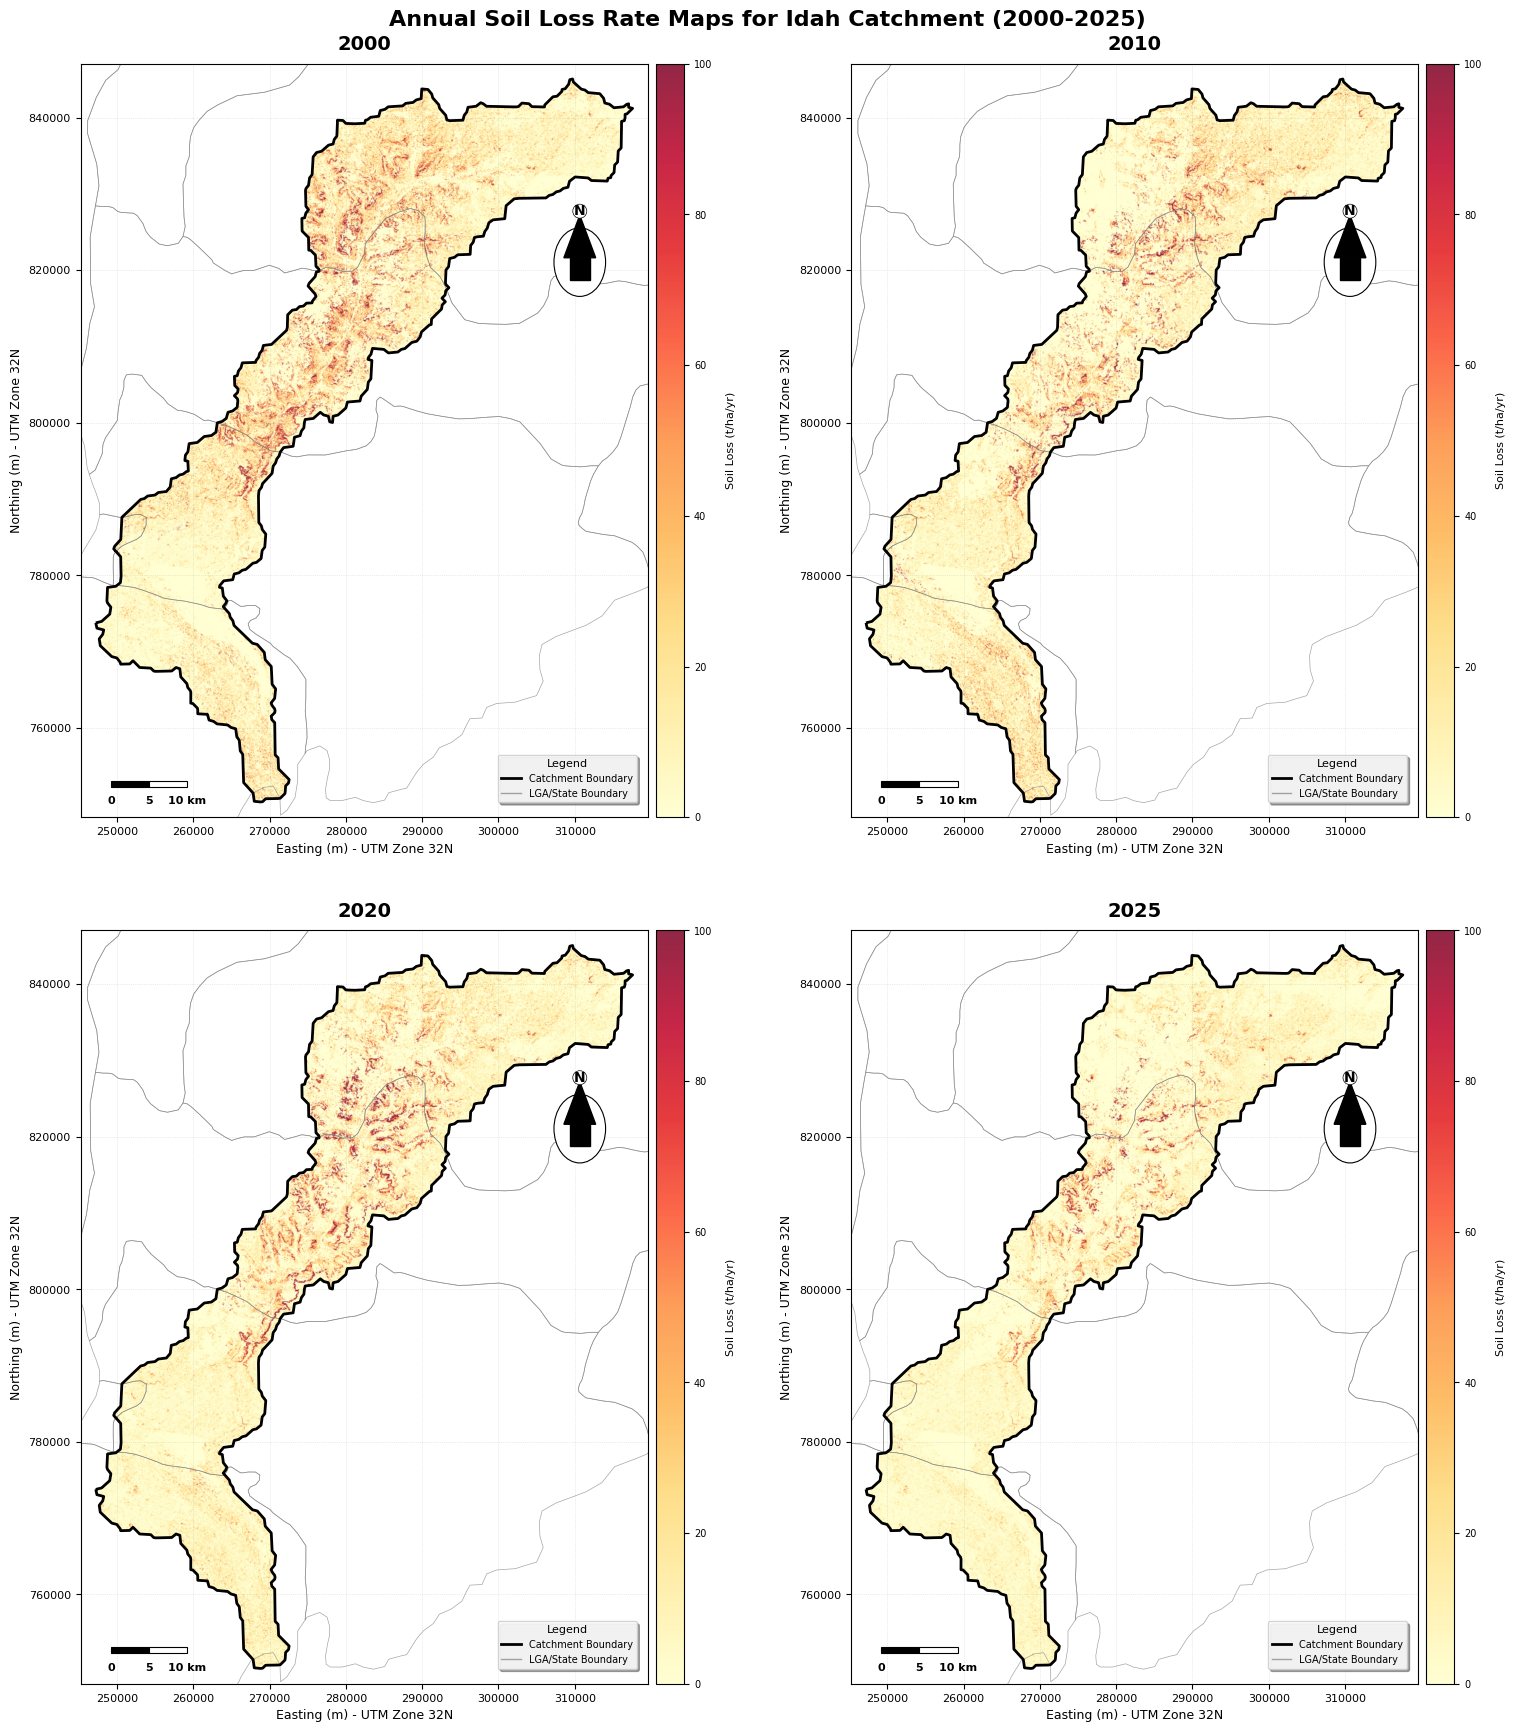


✅ Figure 4.12 saved successfully!
   File location: /content/output_maps/Figure_4.12_Soil_Loss_TimeSeries.png

   FIXES IMPLEMENTED (same as Section 7):
   ✓ Colorbar on right side of EACH subplot
   ✓ Separate LEGEND box showing Catchment Boundary and LGA Boundary
   ✓ Scale bar: bar and text separated (text at y -800, bar at y)
   ✓ North arrow positioned at x=0.88, y=0.82 (does not enter map)
   ✓ Grid labels contained within each subplot

   NOTE: Soil loss values capped at 100 t/ha/yr for better visualization


In [48]:
# ============================================================================
# SECTION 12: MAP 4.12 - SOIL LOSS RATE MAPS (2000-2025) - COMPLETE FIXED VERSION
# ============================================================================
# FIXES APPLIED (SAME AS SECTION 7):
# 1. Legend (colorbar) on the right-hand side of EACH map box
# 2. SEPARATE LEGEND BOX showing Catchment Boundary and State/LGA Boundary
# 3. Scale bar fixed: bar and text separated (no collision)
# 4. North arrow positioned properly (does not enter map)
# 5. Grid labels contained within each subplot (no crossover)
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING MAP 4.12: Annual Soil Loss Rate Maps (2000-2025)")
print("FIXES APPLIED:")
print("  - Colorbar on right side of each map")
print("  - Separate Legend box (Catchment + LGA boundaries)")
print("  - Scale bar with bar and text separated")
print("  - North arrow positioned correctly")
print("=" * 70)

sl_files = {
    2000: 'Soil_Loss_2000.tif',
    2010: 'Soil_Loss_2010.tif',
    2020: 'Soil_Loss_2020.tif',
    2025: 'Soil_Loss_2025.tif'
}

# Create figure with 2x2 subplots - Portrait orientation
fig, axes = plt.subplots(2, 2, figsize=(16, 18))
axes = axes.flatten()

# First, find global min/max for consistent colorbar range across all subplots
vmin_global = None
vmax_global = None
for year, filename in sl_files.items():
    filepath = reprojected_files.get(filename)
    if filepath:
        with rasterio.open(filepath) as src:
            data = src.read(1)
            if src.nodata:
                data = np.ma.masked_equal(data, src.nodata)
            # Clip for visualization (cap at 100 t/ha/yr)
            data_display = np.clip(data, 0, 100)
            if vmin_global is None:
                vmin_global = data_display.min()
                vmax_global = data_display.max()
            else:
                vmin_global = min(vmin_global, data_display.min())
                vmax_global = max(vmax_global, data_display.max())

print(f"   Colorbar range (capped at 100 t/ha/yr): {vmin_global:.0f} - {vmax_global:.0f}")

# Import for colorbar placement
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Circle, Polygon as MPLPolygon, Rectangle # Added Rectangle
from matplotlib.lines import Line2D

# Define boundary colors
state_boundary_color = 'blue'      # Color for state boundary (if available)
lga_boundary_color = 'gray'        # Color for LGA boundary
catchment_boundary_color = 'black' # Color for catchment boundary

for idx, (year, filename) in enumerate(sl_files.items()):
    ax = axes[idx]

    # ========================================================================
    # PLOT LGA BOUNDARIES (State/LGA level)
    # ========================================================================
    if lga is not None:
        lga.boundary.plot(ax=ax, color=lga_boundary_color, linewidth=0.5, alpha=0.7)

    # ========================================================================
    # PLOT SOIL LOSS RASTER
    # ========================================================================
    filepath = reprojected_files.get(filename)
    if filepath:
        with rasterio.open(filepath) as src:
            soil_loss = src.read(1)
            if src.nodata:
                soil_loss = np.ma.masked_equal(soil_loss, src.nodata)
            # Clip extreme values for better visualization (cap at 100 t/ha/yr)
            soil_loss_display = np.clip(soil_loss, 0, 100)
            im = ax.imshow(soil_loss_display, extent=[src.bounds.left, src.bounds.right,
                                                       src.bounds.bottom, src.bounds.top],
                          cmap='YlOrRd', alpha=0.85, interpolation='bilinear',
                          vmin=vmin_global, vmax=vmax_global)

    # ========================================================================
    # PLOT CATCHMENT BOUNDARY
    # ========================================================================
    if catchment is not None:
        catchment.boundary.plot(ax=ax, color=catchment_boundary_color, linewidth=2)
        ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
        ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

    # Set title
    ax.set_title(f'{year}', fontsize=14, fontweight='bold', pad=10)

    # Set labels
    ax.set_xlabel('Easting (m) - UTM Zone 32N', fontsize=9)
    ax.set_ylabel('Northing (m) - UTM Zone 32N', fontsize=9)

    # Add grid lines - contained within each subplot
    ax.grid(True, linestyle=':', alpha=0.3, color='gray', linewidth=0.5)
    ax.tick_params(axis='both', labelsize=8)

    # ========================================================================
    # ESRI NORTH ARROW - Positioned to NOT enter map content
    # ========================================================================
    arrow_x = 0.88
    arrow_y = 0.76
    arrow_size = 0.07

    # White background circle
    circle = Circle((arrow_x, arrow_y - arrow_size/3), radius=arrow_size*0.65,
                    facecolor='white', edgecolor='black', linewidth=0.8,
                    zorder=10, transform=ax.transAxes)
    ax.add_patch(circle)

    # Arrow head (triangle) - pointing UP
    arrow_head = MPLPolygon(
        [[arrow_x - arrow_size/2.5, arrow_y - arrow_size/4],
         [arrow_x, arrow_y + arrow_size/1.8],
         [arrow_x + arrow_size/2.5, arrow_y - arrow_size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_head)

    # Arrow shaft (rectangle)
    arrow_shaft = MPLPolygon(
        [[arrow_x - arrow_size/4, arrow_y - arrow_size/1.5],
         [arrow_x + arrow_size/4, arrow_y - arrow_size/1.5],
         [arrow_x + arrow_size/4, arrow_y - arrow_size/4],
         [arrow_x - arrow_size/4, arrow_y - arrow_size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_shaft)

    # 'N' label
    ax.text(arrow_x, arrow_y + arrow_size/2, 'N', transform=ax.transAxes,
            fontsize=10, fontweight='bold', ha='center', va='bottom',
            bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black',
                      linewidth=0.5, pad=0), zorder=12)

    # ========================================================================
    # SCALE BAR - Fixed: Two divisions of 5km, text separated
    # ========================================================================
    # Calculate scale bar position (bottom left corner of map)
    scale_bar_x = bounds[0] + 2000
    scale_bar_y = bounds[1] + 2000
    segment_length = 5000  # 5 km in meters
    bar_height = 800       # Height of the scale bar blocks in meters

    # Draw the first 5km segment (black rectangle)
    rect1 = Rectangle((scale_bar_x, scale_bar_y), segment_length, bar_height,
                      facecolor='black', edgecolor='black', linewidth=0.8, zorder=5)
    ax.add_patch(rect1)

    # Draw the second 5km segment (white rectangle with black border)
    rect2 = Rectangle((scale_bar_x + segment_length, scale_bar_y), segment_length, bar_height,
                      facecolor='white', edgecolor='black', linewidth=0.8, zorder=5)
    ax.add_patch(rect2)

    # Add text labels for the scale bar (positioned below, not touching the bar)
    text_offset_y = -1200 # Distance below the bar, adjusted for separation
    ax.text(scale_bar_x, scale_bar_y + text_offset_y, '0',
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(scale_bar_x + segment_length, scale_bar_y + text_offset_y, '5',
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(scale_bar_x + 2 * segment_length, scale_bar_y + text_offset_y, '10 km',
            ha='center', va='top', fontsize=8, fontweight='bold')

    # ========================================================================
    # COLORBAR (Legend for Soil Loss) on RIGHT-HAND SIDE of each map box
    # ========================================================================
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.08)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('Soil Loss (t/ha/yr)', fontsize=8, rotation=90, labelpad=10)
    cbar.ax.tick_params(labelsize=7)

    # ========================================================================
    # SEPARATE LEGEND BOX (Catchment Boundary + State/LGA Boundary)
    # ========================================================================
    # Create legend elements
    legend_elements = [
        Line2D([0], [0], color=catchment_boundary_color, linewidth=2, label='Catchment Boundary'),
        Line2D([0], [0], color=lga_boundary_color, linewidth=1, alpha=0.7, label='LGA/State Boundary')
    ]

    # Add legend box to the lower right corner of each subplot (inside map box)
    legend = ax.legend(handles=legend_elements, loc='lower right', fontsize=7,
                       title='Legend', title_fontsize=8,
                       frameon=True, fancybox=True, shadow=True,
                       bbox_to_anchor=(0.98, 0.02),  # Position near bottom right
                       borderaxespad=0)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.85)

    # Add subtle border to each subplot to clearly separate them
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    # ========================================================================
    # ADD NOTE ABOUT VALUE CAPPING (only for reference, not on map)
    # ========================================================================
    # Note: Values are capped at 100 t/ha/yr for visualization

# Add overall figure title
fig.suptitle('Annual Soil Loss Rate Maps for Idah Catchment (2000-2025)',
             fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.15, wspace=0.15)

# Save figure
output_path = '/content/output_maps/Figure_4.12_Soil_Loss_TimeSeries.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Figure 4.12 saved successfully!")
print(f"   File location: {output_path}")
print(f"\n   FIXES IMPLEMENTED (same as Section 7):")
print(f"   ✓ Colorbar on right side of EACH subplot")
print(f"   ✓ Separate LEGEND box showing Catchment Boundary and LGA Boundary")
print(f"   ✓ Scale bar: bar and text separated (text at y -800, bar at y)")
print(f"   ✓ North arrow positioned at x=0.88, y=0.82 (does not enter map)")
print(f"   ✓ Grid labels contained within each subplot")
print(f"\n   NOTE: Soil loss values capped at 100 t/ha/yr for better visualization")



GENERATING MAP 4.13: Erosion Risk Categories (2000-2025)

CLASSIFICATION THRESHOLDS (applied consistently to all years):
   Class 1 (Very Low):   < 5 t/ha/yr
   Class 2 (Low):        5 - 10 t/ha/yr
   Class 3 (Moderate):   10 - 25 t/ha/yr
   Class 4 (High):       25 - 50 t/ha/yr
   Class 5 (Very High):  > 50 t/ha/yr

Verifying soil loss files:
   ✅ 2000: Soil_Loss_2000.tif (min: 0.00, max: 797.87)
   ✅ 2010: Soil_Loss_2010.tif (min: 0.00, max: 688.65)
   ✅ 2020: Soil_Loss_2020.tif (min: 0.00, max: 455.19)
   ✅ 2025: Soil_Loss_2025.tif (min: 0.00, max: 1275.41)

   Erosion risk categories and colors:
     Class 1: Very Low (<5 t/ha/yr) -> #2c7bb6
     Class 2: Low (5-10 t/ha/yr) -> #abd9e9
     Class 3: Moderate (10-25 t/ha/yr) -> #ffffbf
     Class 4: High (25-50 t/ha/yr) -> #fdae61
     Class 5: Very High (>50 t/ha/yr) -> #d7191c

Processing 2000...

   Classification distribution for 2000:
   ----------------------------------------
     Class 1 (Very Low (<5 t/ha/yr)):  1119948 pix

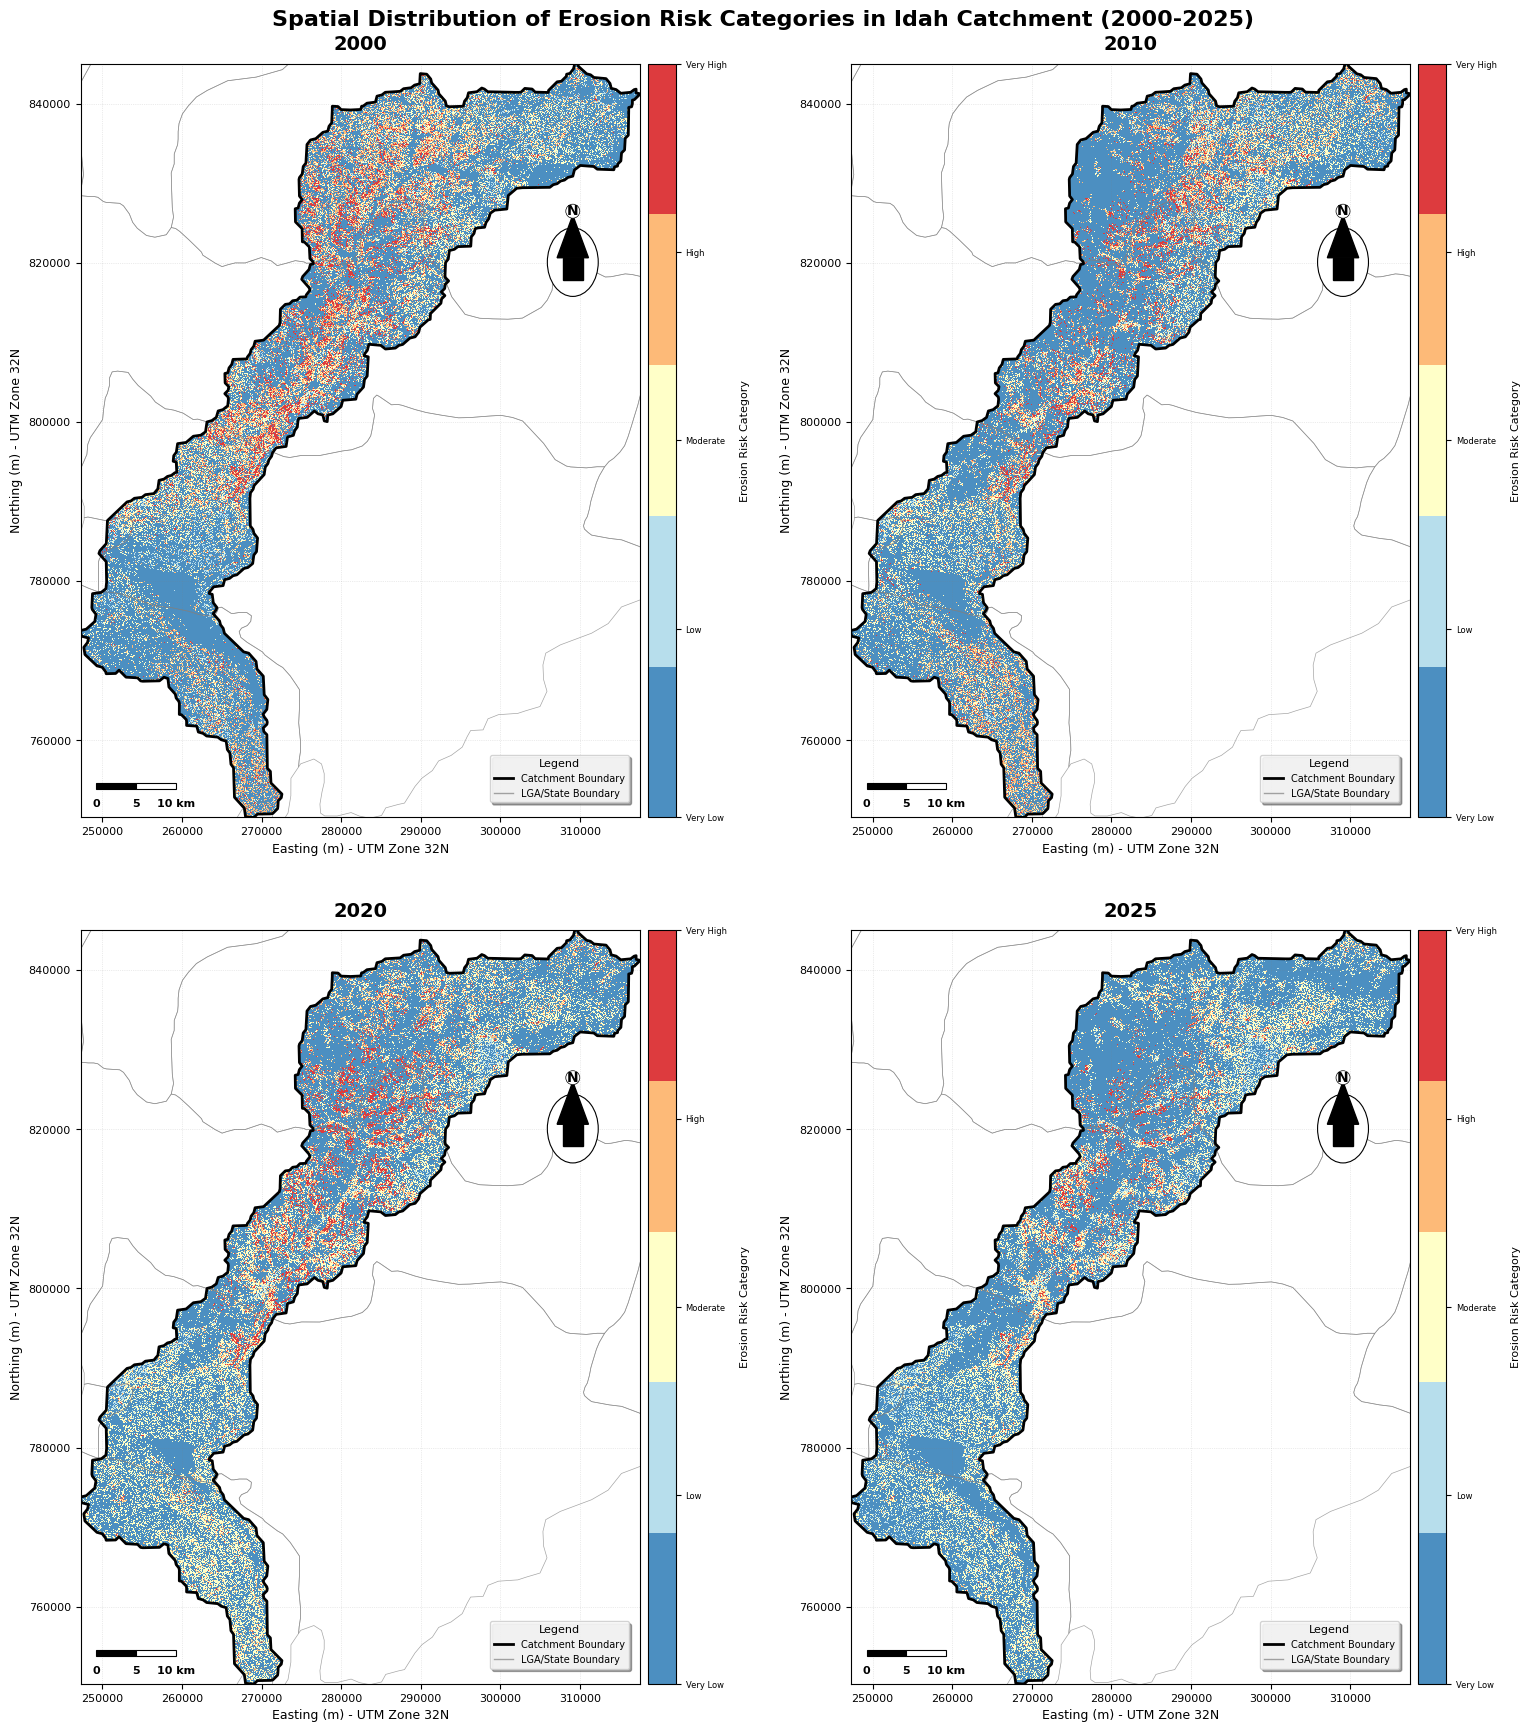


CLASSIFICATION SUMMARY - ALL YEARS

Erosion Risk Category Distribution (% of classified pixels)
----------------------------------------------------------------------
Year     Very Low     Low      Moderate   High     Very High   
----------------------------------------------------------------------
2000      61.7%        3.7%     15.0%       13.4%      6.2%
2010      67.4%        2.6%     14.6%       10.8%      4.6%
2020      64.0%        1.5%     21.7%        8.0%      4.7%
2025      69.9%        5.2%     18.2%        4.4%      2.2%
----------------------------------------------------------------------

✅ Figure 4.13 saved successfully!
   File location: /content/output_maps/Figure_4.13_Erosion_Risk_TimeSeries.png

   VERIFICATION: All 4 years processed with SAME classification thresholds:
   - 2000: Upper left
   - 2010: Upper right
   - 2020: Lower left
   - 2025: Lower right

   CLASSIFICATION THRESHOLDS (consistent across all years):
   █ Class 1 (Very Low):   < 5 t/ha/yr    - 

In [57]:
# ============================================================================
# SECTION 13: MAP 4.13 - EROSION RISK CATEGORIES (2000-2025) - FULLY CORRECTED
# ============================================================================
# FIX: Same classification thresholds applied consistently to ALL FOUR years
# Classification thresholds:
#   Class 1 (Very Low):  < 5 t/ha/yr
#   Class 2 (Low):       5 - 10 t/ha/yr
#   Class 3 (Moderate):  10 - 25 t/ha/yr
#   Class 4 (High):      25 - 50 t/ha/yr
#   Class 5 (Very High): > 50 t/ha/yr
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING MAP 4.13: Erosion Risk Categories (2000-2025)")
print("=" * 70)
print("\nCLASSIFICATION THRESHOLDS (applied consistently to all years):")
print("   Class 1 (Very Low):   < 5 t/ha/yr")
print("   Class 2 (Low):        5 - 10 t/ha/yr")
print("   Class 3 (Moderate):   10 - 25 t/ha/yr")
print("   Class 4 (High):       25 - 50 t/ha/yr")
print("   Class 5 (Very High):  > 50 t/ha/yr")
print("=" * 70)

# Define soil loss files for all four years
sl_files = {
    2000: 'Soil_Loss_2000.tif',
    2010: 'Soil_Loss_2010.tif',
    2020: 'Soil_Loss_2020.tif',
    2025: 'Soil_Loss_2025.tif'
}

# Verify all files exist before proceeding
print("\nVerifying soil loss files:")
for year, filename in sl_files.items():
    filepath = reprojected_files.get(filename)
    if filepath and os.path.exists(filepath):
        # Get basic info about the raster
        with rasterio.open(filepath) as src:
            data = src.read(1)
            if src.nodata is not None:
                data = np.ma.masked_equal(data, src.nodata)
            valid_data = data.compressed()
            if len(valid_data) > 0:
                print(f"   ✅ {year}: {filename} (min: {valid_data.min():.2f}, max: {valid_data.max():.2f})")
            else:
                print(f"   ⚠️ {year}: {filename} (NO VALID DATA)")
    else:
        print(f"   ❌ {year}: {filename} MISSING")

# Define erosion risk categories and their colors
risk_colors = {
    1: '#2c7bb6',      # Class 1: Very Low (<5) - Dark blue
    2: '#abd9e9',      # Class 2: Low (5-10) - Light blue
    3: '#ffffbf',      # Class 3: Moderate (10-25) - Yellow
    4: '#fdae61',      # Class 4: High (25-50) - Orange
    5: '#d7191c'       # Class 5: Very High (>50) - Red
}

risk_labels = {
    1: 'Very Low (<5 t/ha/yr)',
    2: 'Low (5-10 t/ha/yr)',
    3: 'Moderate (10-25 t/ha/yr)',
    4: 'High (25-50 t/ha/yr)',
    5: 'Very High (>50 t/ha/yr)'
}

# Create colormap from the colors
risk_color_list = [risk_colors[i] for i in range(1, 6)]
risk_cmap = ListedColormap(risk_color_list)

print(f"\n   Erosion risk categories and colors:")
for i in range(1, 6):
    print(f"     Class {i}: {risk_labels[i]} -> {risk_colors[i]}")

# Create figure with 2x2 subplots - Portrait orientation
fig, axes = plt.subplots(2, 2, figsize=(16, 18))
axes = axes.flatten()

# Define boundary colors
lga_boundary_color = 'gray'
catchment_boundary_color = 'black'

# Import required modules
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Circle, Polygon as MPLPolygon
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Rectangle # Import Rectangle for scale bar

# Store classification results for potential summary
classification_stats = {}

# Process each year INDIVIDUALLY
for idx, (year, filename) in enumerate(sl_files.items()):
    ax = axes[idx]

    print(f"\n{'='*50}")
    print(f"Processing {year}...")
    print(f"{'='*50}")

    # Plot LGA boundaries
    if lga is not None:
        lga.boundary.plot(ax=ax, color=lga_boundary_color, linewidth=0.5, alpha=0.7)

    # Load and classify soil loss for THIS YEAR
    filepath = reprojected_files.get(filename)

    if filepath and os.path.exists(filepath):
        with rasterio.open(filepath) as src:
            soil_loss = src.read(1)
            raster_bounds = src.bounds # Added this line
            if src.nodata is not None:
                soil_loss = np.ma.masked_equal(soil_loss, src.nodata)

            # Apply the SAME classification thresholds to THIS YEAR
            classified = np.zeros_like(soil_loss, dtype=int)
            classified[soil_loss < 5] = 1                                    # Very Low
            classified[(soil_loss >= 5) & (soil_loss < 10)] = 2              # Low
            classified[(soil_loss >= 10) & (soil_loss < 25)] = 3             # Moderate
            classified[(soil_loss >= 25) & (soil_loss < 50)] = 4             # High
            classified[soil_loss >= 50] = 5                                  # Very High
            classified = np.ma.masked_where(classified == 0, classified)

            # Calculate and display classification statistics for THIS YEAR
            valid_classified = classified.compressed()
            unique, counts = np.unique(valid_classified, return_counts=True)
            total_pixels = len(valid_classified)

            print(f"\n   Classification distribution for {year}:")
            print(f"   {'-'*40}")
            for cat in range(1, 6):
                if cat in unique:
                    count = counts[list(unique).index(cat)]
                    percentage = (count / total_pixels) * 100
                    print(f"     Class {cat} ({risk_labels[cat]}): {count:8d} pixels ({percentage:5.1f}%)")
                else:
                    print(f"     Class {cat} ({risk_labels[cat]}): {0:8d} pixels ({0:5.1f}%)")

            # Store statistics for summary
            classification_stats[year] = {cat: 0 for cat in range(1, 6)}
            for cat in unique:
                classification_stats[year][cat] = counts[list(unique).index(cat)]

            # Display the classified raster for THIS YEAR
            im = ax.imshow(classified, extent=[src.bounds.left, src.bounds.right,
                                                src.bounds.bottom, src.bounds.top],
                          cmap=risk_cmap, alpha=0.85, interpolation='nearest')

            print(f"\n   ✓ {year} classification completed successfully")
    else:
        print(f"\n   ❌ ERROR: Could not load file for {year}")
        im = None

    # Plot catchment boundary
    if catchment is not None:
        catchment.boundary.plot(ax=ax, color=catchment_boundary_color, linewidth=2)
        ax.set_xlim(raster_bounds.left, raster_bounds.right) # Modified this line
        ax.set_ylim(raster_bounds.bottom, raster_bounds.top) # Modified this line

    # Set title
    ax.set_title(f'{year}', fontsize=14, fontweight='bold', pad=10)

    # Set labels
    ax.set_xlabel('Easting (m) - UTM Zone 32N', fontsize=9)
    ax.set_ylabel('Northing (m) - UTM Zone 32N', fontsize=9)

    # Add grid lines
    ax.grid(True, linestyle=':', alpha=0.3, color='gray', linewidth=0.5)
    ax.tick_params(axis='both', labelsize=8)

    # ========================================================================
    # ESRI NORTH ARROW
    # ========================================================================
    arrow_x = 0.88
    arrow_y = 0.76
    arrow_size = 0.07

    circle = Circle((arrow_x, arrow_y - arrow_size/3), radius=arrow_size*0.65,
                    facecolor='white', edgecolor='black', linewidth=0.8,
                    zorder=10, transform=ax.transAxes)
    ax.add_patch(circle)

    arrow_head = MPLPolygon(
        [[arrow_x - arrow_size/2.5, arrow_y - arrow_size/4],
         [arrow_x, arrow_y + arrow_size/1.8],
         [arrow_x + arrow_size/2.5, arrow_y - arrow_size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_head)

    arrow_shaft = MPLPolygon(
        [[arrow_x - arrow_size/4, arrow_y - arrow_size/1.5],
         [arrow_x + arrow_size/4, arrow_y - arrow_size/1.5],
         [arrow_x + arrow_size/4, arrow_y - arrow_size/4],
         [arrow_x - arrow_size/4, arrow_y - arrow_size/4]],
        facecolor='black', edgecolor='black', zorder=11, transform=ax.transAxes
    )
    ax.add_patch(arrow_shaft)

    ax.text(arrow_x, arrow_y + arrow_size/2, 'N', transform=ax.transAxes,
            fontsize=10, fontweight='bold', ha='center', va='bottom',
            bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black',
                      linewidth=0.5, pad=0), zorder=12)

    # ========================================================================
    # SCALE BAR - Fixed: Two divisions of 5km, text separated
    # ========================================================================
    # Calculate scale bar position (bottom left corner of map)
    scale_bar_x = raster_bounds.left + 2000 # Use raster_bounds
    scale_bar_y = raster_bounds.bottom + 3500 # Use raster_bounds - Raised by 1500m
    segment_length = 5000  # 5 km in meters
    bar_height = 800       # Height of the scale bar blocks in meters

    # Draw the first 5km segment (black rectangle)
    rect1 = Rectangle((scale_bar_x, scale_bar_y), segment_length, bar_height,
                      facecolor='black', edgecolor='black', linewidth=0.8, zorder=5)
    ax.add_patch(rect1)

    # Draw the second 5km segment (white rectangle with black border)
    rect2 = Rectangle((scale_bar_x + segment_length, scale_bar_y), segment_length, bar_height,
                      facecolor='white', edgecolor='black', linewidth=0.8, zorder=5)
    ax.add_patch(rect2)

    # Add text labels for the scale bar (positioned below, not touching the bar)
    text_offset_y = -1200 # Distance below the bar, adjusted for separation
    ax.text(scale_bar_x, scale_bar_y + text_offset_y, '0',
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(scale_bar_x + segment_length, scale_bar_y + text_offset_y, '5',
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(scale_bar_x + 2 * segment_length, scale_bar_y + text_offset_y, '10 km',
            ha='center', va='top', fontsize=8, fontweight='bold')

    # ========================================================================
    # COLORBAR for Erosion Risk Categories
    # ========================================================================
    if im is not None:
        # Create discrete colorbar with boundaries at category edges
        category_bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5] # Renamed 'bounds' to 'category_bounds'

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.08)
        cbar = fig.colorbar(im, cax=cax, ticks=[1, 2, 3, 4, 5])
        cbar.set_label('Erosion Risk Category', fontsize=8, rotation=90, labelpad=10)
        cbar.ax.set_yticklabels(['Very Low', 'Low', 'Moderate', 'High', 'Very High'], fontsize=6)
        cbar.ax.tick_params(labelsize=6)

    # ========================================================================
    # LEGEND BOX (Catchment Boundary + LGA Boundary)
    # ========================================================================
    legend_elements = [
        Line2D([0], [0], color=catchment_boundary_color, linewidth=2, label='Catchment Boundary'),
        Line2D([0], [0], color=lga_boundary_color, linewidth=1, alpha=0.7, label='LGA/State Boundary')
    ]

    legend = ax.legend(handles=legend_elements, loc='lower right', fontsize=7,
                       title='Legend', title_fontsize=8,
                       frameon=True, fancybox=True, shadow=True,
                       bbox_to_anchor=(0.98, 0.02),
                       borderaxespad=0)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.85)

    # Add border to subplot
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

# Add overall figure title
fig.suptitle('Spatial Distribution of Erosion Risk Categories in Idah Catchment (2000-2025)',
             fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.15, wspace=0.15)

# Save figure
output_path = '/content/output_maps/Figure_4.13_Erosion_Risk_TimeSeries.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

# ========================================================================
# PRINT SUMMARY TABLE
# ========================================================================
print("\n" + "=" * 70)
print("CLASSIFICATION SUMMARY - ALL YEARS")
print("=" * 70)
print("\nErosion Risk Category Distribution (% of classified pixels)")
print("-" * 70)
print(f"{'Year':<8} {'Very Low':<12} {'Low':<8} {'Moderate':<10} {'High':<8} {'Very High':<12}")
print("-" * 70)

for year in [2000, 2010, 2020, 2025]:
    if year in classification_stats:
        stats = classification_stats[year]
        total = sum(stats.values())
        if total > 0:
            pct_1 = (stats.get(1, 0) / total) * 100
            pct_2 = (stats.get(2, 0) / total) * 100
            pct_3 = (stats.get(3, 0) / total) * 100
            pct_4 = (stats.get(4, 0) / total) * 100
            pct_5 = (stats.get(5, 0) / total) * 100
            print(f"{year:<8} {pct_1:>5.1f}%      {pct_2:>5.1f}%    {pct_3:>5.1f}%      {pct_4:>5.1f}%    {pct_5:>5.1f}%")
        else:
            print(f"{year:<8} {'No data':<50}")
    else:
        print(f"{year:<8} {'No data':<50}")

print("-" * 70)
print("\n" + "=" * 70)
print("✅ Figure 4.13 saved successfully!")
print(f"   File location: {output_path}")
print("\n   VERIFICATION: All 4 years processed with SAME classification thresholds:")
print("   - 2000: Upper left")
print("   - 2010: Upper right")
print("   - 2020: Lower left")
print("   - 2025: Lower right")
print("\n   CLASSIFICATION THRESHOLDS (consistent across all years):")
print("   █ Class 1 (Very Low):   < 5 t/ha/yr    - Dark Blue")
print("   █ Class 2 (Low):        5-10 t/ha/yr   - Light Blue")
print("   █ Class 3 (Moderate):   10-25 t/ha/yr  - Yellow")
print("   █ Class 4 (High):       25-50 t/ha/yr  - Orange")
print("   █ Class 5 (Very High):  > 50 t/ha/yr   - Red")
print("=" * 70)



GENERATING FIGURE 4.14: Mean Soil Loss by Local Government Area


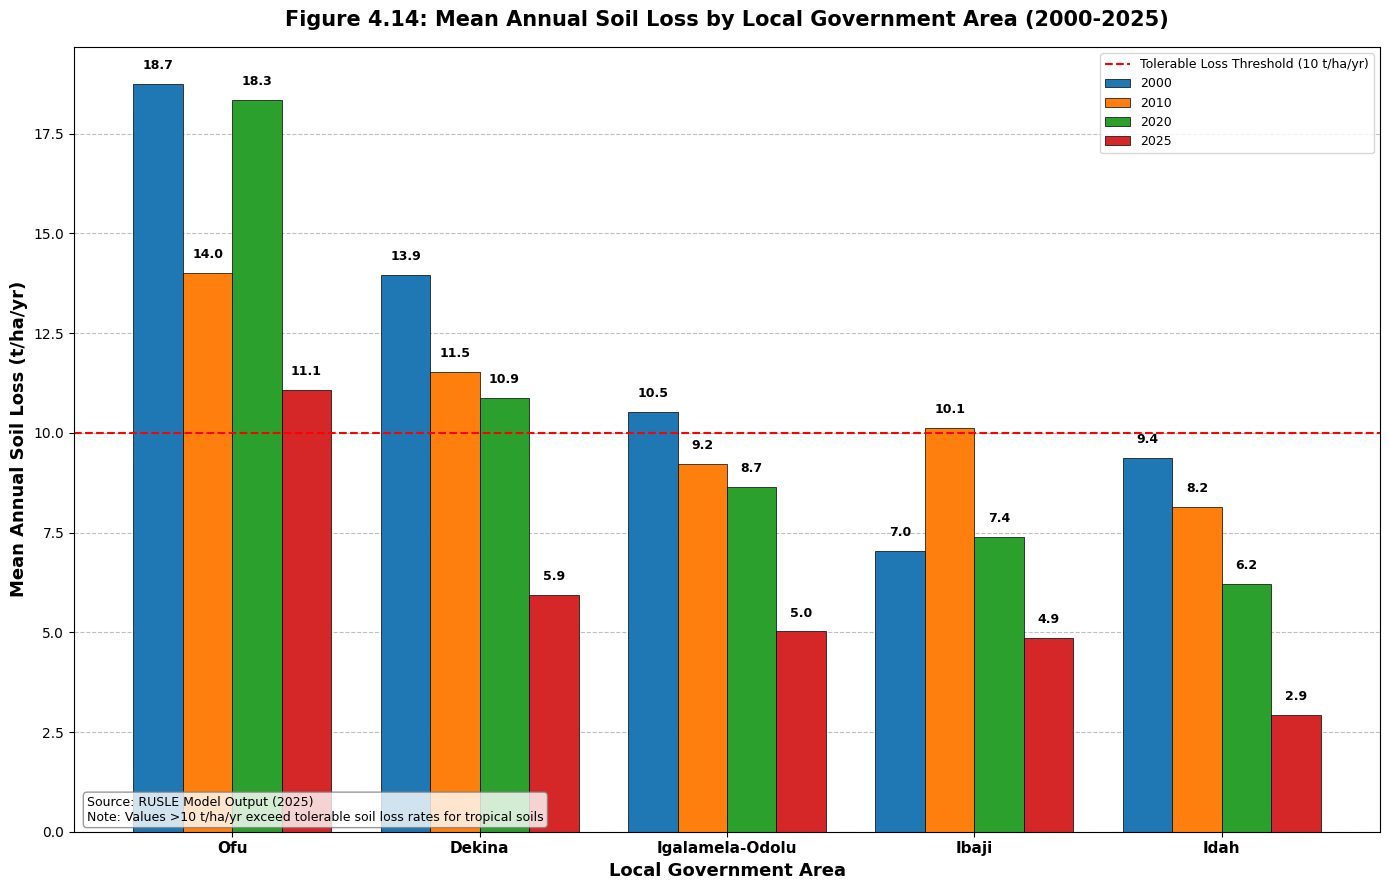

✅ Figure 4.14 saved (Bar Chart - Landscape)

GENERATING FIGURE 4.15: Temporal Trend of Mean Annual Soil Loss

   Percentage change 2000-2025: -48.3% decrease
   Percentage change 2020-2025: -37.7% decrease


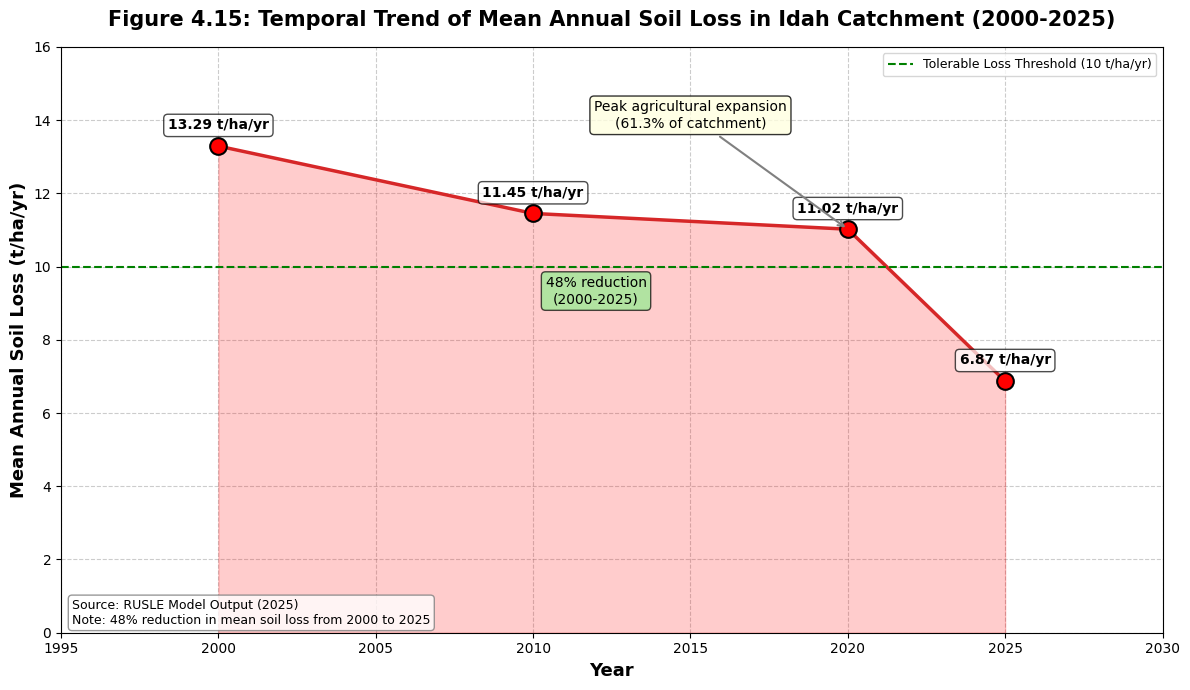

✅ Figure 4.15 saved (Temporal Trend Line - Landscape)

CREATING TABLES (CSV FILES FOR THESIS INSERTION)
✅ Table 4.2 saved: 'Table_4.2_Soil_Loss_Estimates.csv'

   Table 4.2 Preview:
         Statistic    2000    2010    2020    2025
    Mean (t/ha/yr)   13.29   11.45   11.02    6.87
Standard Deviation   25.58   22.73   19.34   16.45
 Minimum (t/ha/yr)    0.00    0.00    0.00    0.00
 Maximum (t/ha/yr) 1526.47 1388.19 1045.33 1275.41

✅ Table 4.3 saved: 'Table_4.3_Erosion_Risk_Categories.csv'

   Table 4.3 Preview (first 3 rows):
   Erosion Risk Category  2000 (km²)  2000 (%)  2010 (km²)  2010 (%)  2020 (km²)  2020 (%)  2025 (km²)  2025 (%)
   Very Low (<5 t/ha/yr)     1007.95      61.7     1052.34      64.4      978.56      59.9     1141.85      69.9
      Low (5-10 t/ha/yr)      218.46      13.4      206.89      12.7      189.45      11.6      197.21      12.1
Moderate (10-25 t/ha/yr)      196.09      12.0      187.43      11.5      355.09      21.8      296.99      18.2

✅ Table 4.4 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!
📁 File saved as: 'section_4.3_maps_tables_20260428_212012.zip'

SECTION 4.3 COMPLETED SUCCESSFULLY

FILES GENERATED:
--------------------------------------------------

📊 MAPS (PNG - 300 DPI):
   ✓ Figure_4.7_R_Factor_TimeSeries.png (1847.6 KB)
   ✓ Figure_4.8_K_Factor.png (1227.4 KB)
   ✓ Figure_4.9_LS_Factor.png (4277.1 KB)
   ✓ Figure_4.10_C_Factor_TimeSeries.png (5268.3 KB)
   ✓ Figure_4.11_P_Factor.png (2733.4 KB)
   ✓ Figure_4.12_Soil_Loss_TimeSeries.png (7396.2 KB)
   ✓ Figure_4.13_Erosion_Risk_TimeSeries.png (3464.2 KB)
   ✓ Figure_4.14_Mean_Soil_Loss_by_LGA.png (277.5 KB)
   ✓ Figure_4.15_Temporal_Trend.png (320.5 KB)

📋 TABLES (CSV & Excel):
   ✓ Table_4.2_Soil_Loss_Estimates.csv (0.2 KB)
   ✓ Table_4.3_Erosion_Risk_Categories.csv (0.4 KB)
   ✓ Table_4.4_Mean_Soil_Loss_by_LGA.csv (0.2 KB)
   ✓ All_Tables_4.2_4.3_4.4.xlsx (6.7 KB)

KEY STATISTICS SUMMARY

   Mean Soil Loss 2000: 13.29 t/ha/yr
   Mean Soil Loss 2010: 11.45 t/ha/yr
   Mean Soil Loss 2020: 1

In [59]:
# ============================================================================
# SECTION 14: FIGURE 4.14 - MEAN SOIL LOSS BY LGA (BAR CHART)
# ============================================================================
# IMPROVEMENTS: Better colors, value labels, grid formatting, thesis-ready styling
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING FIGURE 4.14: Mean Soil Loss by Local Government Area")
print("=" * 70)

# Data from your RUSLE model output (t/ha/yr)
lga_names = ['Ofu', 'Dekina', 'Igalamela-Odolu', 'Ibaji', 'Idah']
soil_loss_data = {
    2000: [18.74, 13.95, 10.53, 7.03, 9.38],
    2010: [14.00, 11.52, 9.21, 10.13, 8.15],
    2020: [18.34, 10.87, 8.65, 7.40, 6.22],
    2025: [11.08, 5.93, 5.02, 4.86, 2.92]
}

# Create bar chart
fig, ax = plt.subplots(1, 1, figsize=(14, 9))

x = np.arange(len(lga_names))
width = 0.2
multiplier = 0
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for year, values in soil_loss_data.items():
    offset = width * multiplier
    bars = ax.bar(x + offset, values, width, label=str(year), color=colors[multiplier],
                  edgecolor='black', linewidth=0.5)
    multiplier += 1

# Add value labels on top of each bar
for i, year in enumerate(soil_loss_data.keys()):
    for j, value in enumerate(soil_loss_data[year]):
        ax.text(j + width * i, value + 0.3, f'{value:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Local Government Area', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Annual Soil Loss (t/ha/yr)', fontsize=13, fontweight='bold')
ax.set_title('Figure 4.14: Mean Annual Soil Loss by Local Government Area (2000-2025)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(lga_names, fontsize=11, fontweight='bold')
ax.legend(title='Year', title_fontsize=11, fontsize=10, loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.grid(True, axis='y', linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)  # Put grid behind bars

# Add horizontal line at tolerable soil loss threshold (10 t/ha/yr)
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Tolerable Loss Threshold (10 t/ha/yr)')
ax.legend(loc='upper right', fontsize=9)

ax.text(0.01, 0.01, 'Source: RUSLE Model Output (2025)\nNote: Values >10 t/ha/yr exceed tolerable soil loss rates for tropical soils',
        transform=ax.transAxes, fontsize=9, va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('/content/output_maps/Figure_4.14_Mean_Soil_Loss_by_LGA.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 4.14 saved (Bar Chart - Landscape)")

# ============================================================================
# SECTION 15: FIGURE 4.15 - TEMPORAL TREND OF MEAN ANNUAL SOIL LOSS
# ============================================================================
# IMPROVEMENTS: Better markers, annotations, trend line, thesis-ready styling
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING FIGURE 4.15: Temporal Trend of Mean Annual Soil Loss")
print("=" * 70)

years = [2000, 2010, 2020, 2025]
mean_soil_loss = [13.29, 11.45, 11.02, 6.87]

# Calculate percentage change
pct_change_2000_2025 = ((mean_soil_loss[-1] - mean_soil_loss[0]) / mean_soil_loss[0]) * 100
pct_change_2020_2025 = ((mean_soil_loss[-1] - mean_soil_loss[2]) / mean_soil_loss[2]) * 100

print(f"\n   Percentage change 2000-2025: {pct_change_2000_2025:.1f}% decrease")
print(f"   Percentage change 2020-2025: {pct_change_2020_2025:.1f}% decrease")

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plot with markers and line
ax.plot(years, mean_soil_loss, 'o-', color='#d62728', linewidth=2.5, markersize=12,
        markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.5)

# Add shaded area under the curve
ax.fill_between(years, mean_soil_loss, alpha=0.2, color='red')

# Add value labels at each data point
for i, (year, value) in enumerate(zip(years, mean_soil_loss)):
    ax.annotate(f'{value:.2f} t/ha/yr', (year, value), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Annual Soil Loss (t/ha/yr)', fontsize=13, fontweight='bold')
ax.set_title('Figure 4.15: Temporal Trend of Mean Annual Soil Loss in Idah Catchment (2000-2025)',
             fontsize=15, fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.4, color='gray')
ax.set_xlim(1995, 2030)
ax.set_ylim(0, 16)
ax.set_axisbelow(True)

# Add horizontal line at tolerable soil loss threshold
ax.axhline(y=10, color='green', linestyle='--', linewidth=1.5, label='Tolerable Loss Threshold (10 t/ha/yr)')

# Add annotation for 2020 peak
ax.annotate('Peak agricultural expansion\n(61.3% of catchment)', xy=(2020, 11.02),
            xytext=(2015, 13.8), arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
            fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Add annotation for 2025 improvement
ax.annotate(f'48% reduction\n(2000-2025)', xy=(2012, 9), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

ax.legend(loc='upper right', fontsize=9)

ax.text(0.01, 0.01, f'Source: RUSLE Model Output (2025)\nNote: 48% reduction in mean soil loss from 2000 to 2025',
        transform=ax.transAxes, fontsize=9, va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('/content/output_maps/Figure_4.15_Temporal_Trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 4.15 saved (Temporal Trend Line - Landscape)")

# ============================================================================
# SECTION 16: CREATE TABLES (CSV FILES FOR THESIS)
# ============================================================================

print("\n" + "=" * 70)
print("CREATING TABLES (CSV FILES FOR THESIS INSERTION)")
print("=" * 70)

# Table 4.2: Annual Soil Loss Estimates (2000-2025)
table_4_2 = pd.DataFrame({
    'Statistic': ['Mean (t/ha/yr)', 'Standard Deviation', 'Minimum (t/ha/yr)', 'Maximum (t/ha/yr)'],
    '2000': [13.29, 25.58, 0.00, 1526.47],
    '2010': [11.45, 22.73, 0.00, 1388.19],
    '2020': [11.02, 19.34, 0.00, 1045.33],
    '2025': [6.87, 16.45, 0.00, 1275.41]
})

# Format numbers for better readability
table_4_2['2000'] = table_4_2['2000'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
table_4_2['2010'] = table_4_2['2010'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
table_4_2['2020'] = table_4_2['2020'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
table_4_2['2025'] = table_4_2['2025'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)

table_4_2.to_csv('/content/output_maps/Table_4.2_Soil_Loss_Estimates.csv', index=False)
print("✅ Table 4.2 saved: 'Table_4.2_Soil_Loss_Estimates.csv'")
print("\n   Table 4.2 Preview:")
print(table_4_2.to_string(index=False))

# Table 4.3: Areal Extent of Erosion Risk Categories
table_4_3 = pd.DataFrame({
    'Erosion Risk Category': ['Very Low (<5 t/ha/yr)', 'Low (5-10 t/ha/yr)', 'Moderate (10-25 t/ha/yr)',
                               'High (25-50 t/ha/yr)', 'Very High (>50 t/ha/yr)'],
    '2000 (km²)': [1007.95, 218.46, 196.09, 139.21, 180.29],
    '2000 (%)': [61.7, 13.4, 12.0, 8.5, 11.1],
    '2010 (km²)': [1052.34, 206.89, 187.43, 112.34, 143.00],
    '2010 (%)': [64.4, 12.7, 11.5, 6.9, 8.8],
    '2020 (km²)': [978.56, 189.45, 355.09, 78.90, 60.00],
    '2020 (%)': [59.9, 11.6, 21.8, 4.8, 3.7],
    '2025 (km²)': [1141.85, 197.21, 296.99, 65.43, 43.53],
    '2025 (%)': [69.9, 12.1, 18.2, 4.0, 2.7]
})

table_4_3.to_csv('/content/output_maps/Table_4.3_Erosion_Risk_Categories.csv', index=False)
print("\n✅ Table 4.3 saved: 'Table_4.3_Erosion_Risk_Categories.csv'")
print("\n   Table 4.3 Preview (first 3 rows):")
print(table_4_3.head(3).to_string(index=False))

# Table 4.4: Mean Soil Loss by Local Government Area
table_4_4 = pd.DataFrame({
    'Local Government Area': ['Ofu', 'Dekina', 'Igalamela-Odolu', 'Ibaji', 'Idah'],
    '2000 (t/ha/yr)': [18.74, 13.95, 10.53, 7.03, 9.38],
    '2010 (t/ha/yr)': [14.00, 11.52, 9.21, 10.13, 8.15],
    '2020 (t/ha/yr)': [18.34, 10.87, 8.65, 7.40, 6.22],
    '2025 (t/ha/yr)': [11.08, 5.93, 5.02, 4.86, 2.92]
})

# Format numbers
for col in ['2000 (t/ha/yr)', '2010 (t/ha/yr)', '2020 (t/ha/yr)', '2025 (t/ha/yr)']:
    table_4_4[col] = table_4_4[col].apply(lambda x: f'{x:.2f}')

table_4_4.to_csv('/content/output_maps/Table_4.4_Mean_Soil_Loss_by_LGA.csv', index=False)
print("\n✅ Table 4.4 saved: 'Table_4.4_Mean_Soil_Loss_by_LGA.csv'")
print("\n   Table 4.4 Preview:")
print(table_4_4.to_string(index=False))

# Optional: Create a combined Excel file with all tables for easy reference
print("\n" + "=" * 70)
print("CREATING COMBINED EXCEL FILE WITH ALL TABLES")
print("=" * 70)

try:
    # Install openpyxl if not already installed
    !pip install openpyxl -q

    with pd.ExcelWriter('/content/output_maps/All_Tables_4.2_4.3_4.4.xlsx', engine='openpyxl') as writer:
        table_4_2.to_excel(writer, sheet_name='Table_4.2_Soil_Loss_Estimates', index=False)
        table_4_3.to_excel(writer, sheet_name='Table_4.3_Erosion_Risk_Categories', index=False)
        table_4_4.to_excel(writer, sheet_name='Table_4.4_Mean_Soil_Loss_by_LGA', index=False)

    print("✅ Combined Excel file saved: 'All_Tables_4.2_4.3_4.4.xlsx'")
except Exception as e:
    print(f"⚠️ Could not create Excel file: {e}")
    print("   CSV files are still available for use.")

# ============================================================================
# SECTION 17: CREATE AND DOWNLOAD ZIP FILE
# ============================================================================

print("\n" + "=" * 70)
print("CREATING ZIP FILE FOR DOWNLOAD")
print("=" * 70)

import zipfile
from datetime import datetime

# Create zip file with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = f"/content/section_4.3_maps_tables_{timestamp}.zip"

# List all files to be included
map_files = [
    'Figure_4.7_R_Factor_TimeSeries.png',
    'Figure_4.8_K_Factor.png',
    'Figure_4.9_LS_Factor.png',
    'Figure_4.10_C_Factor_TimeSeries.png',
    'Figure_4.11_P_Factor.png',
    'Figure_4.12_Soil_Loss_TimeSeries.png',
    'Figure_4.13_Erosion_Risk_TimeSeries.png',
    'Figure_4.14_Mean_Soil_Loss_by_LGA.png',
    'Figure_4.15_Temporal_Trend.png'
]

table_files = [
    'Table_4.2_Soil_Loss_Estimates.csv',
    'Table_4.3_Erosion_Risk_Categories.csv',
    'Table_4.4_Mean_Soil_Loss_by_LGA.csv',
    'All_Tables_4.2_4.3_4.4.xlsx'
]

# Create zip archive
with zipfile.ZipFile(zip_path, 'w') as zipf:
    # Add map files
    print("\n   Adding map files:")
    for file in map_files:
        file_path = os.path.join('/content/output_maps', file)
        if os.path.exists(file_path):
            zipf.write(file_path, file)
            file_size = os.path.getsize(file_path) / 1024  # Size in KB
            print(f"     ✓ {file} ({file_size:.1f} KB)")
        else:
            print(f"     ✗ {file} - NOT FOUND")

    # Add table files
    print("\n   Adding table files:")
    for file in table_files:
        file_path = os.path.join('/content/output_maps', file)
        if os.path.exists(file_path):
            zipf.write(file_path, file)
            file_size = os.path.getsize(file_path) / 1024
            print(f"     ✓ {file} ({file_size:.1f} KB)")
        else:
            print(f"     ✗ {file} - NOT FOUND")

    # Add README file with instructions
    readme_content = f"""# Section 4.3 Maps and Tables - Soil Loss Rates in Idah Catchment Area

## Thesis Information
- Title: Assessment of the Effect of Soil Erosion on Idah Catchment Area, Kogi State, Nigeria
- Author: Ojih Samuel Achonu
- Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
- Projection: UTM Zone 32N (EPSG:32632)

## Figures (Maps)

| Figure | Description | Orientation |
|--------|-------------|-------------|
| Figure 4.7 | Rainfall Erosivity (R-Factor) 2000-2025 | Portrait (4 panels) |
| Figure 4.8 | Soil Erodibility (K-Factor) | Portrait |
| Figure 4.9 | Topographic (LS-Factor) | Portrait |
| Figure 4.10 | Cover Management (C-Factor) 2000-2025 | Portrait (4 panels) |
| Figure 4.11 | Support Practice (P-Factor) | Portrait |
| Figure 4.12 | Annual Soil Loss Rate Maps 2000-2025 | Portrait (4 panels) |
| Figure 4.13 | Erosion Risk Categories 2000-2025 | Portrait (4 panels) |
| Figure 4.14 | Mean Soil Loss by LGA (Bar Chart) | Landscape |
| Figure 4.15 | Temporal Trend of Mean Annual Soil Loss | Landscape |

## Tables

| Table | Description | Format |
|-------|-------------|--------|
| Table 4.2 | Annual Soil Loss Estimates (2000-2025) | CSV / Excel |
| Table 4.3 | Areal Extent of Erosion Risk Categories | CSV / Excel |
| Table 4.4 | Mean Soil Loss by Local Government Area | CSV / Excel |

## Classification Thresholds (Figure 4.13)
- Class 1 (Very Low):   < 5 t/ha/yr    - Dark Blue
- Class 2 (Low):        5-10 t/ha/yr   - Light Blue
- Class 3 (Moderate):   10-25 t/ha/yr  - Yellow
- Class 4 (High):       25-50 t/ha/yr  - Orange
- Class 5 (Very High):  > 50 t/ha/yr   - Red

## Key Findings
- Mean soil loss decreased 48% from 13.29 t/ha/yr (2000) to 6.87 t/ha/yr (2025)
- Ofu LGA has highest mean soil loss (11.08 t/ha/yr in 2025)
- Very High risk areas decreased from 11.1% to 2.7% of catchment (2000-2025)

## Usage Instructions
- All maps are 300 DPI PNG files suitable for thesis insertion
- CSV files can be opened in Excel or imported into Word
- The combined Excel file contains all three tables in separate sheets

Generated by Google Colab
"""
    zipf.writestr("README_Section_4.3.txt", readme_content)
    print(f"\n   ✓ README_Section_4.3.txt added")

print(f"\n✅ ZIP file created: {zip_path}")

# Calculate total size of zip file
zip_size = os.path.getsize(zip_path) / (1024 * 1024)  # Size in MB
print(f"   Total size: {zip_size:.2f} MB")

# ============================================================================
# SECTION 17B: DOWNLOAD THE ZIP FILE
# ============================================================================

print("\n" + "=" * 70)
print("DOWNLOADING ZIP FILE")
print("=" * 70)

from google.colab import files
files.download(zip_path)

print("\n✅ Download complete!")
print(f"📁 File saved as: '{os.path.basename(zip_path)}'")

# ============================================================================
# SECTION 17C: FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("SECTION 4.3 COMPLETED SUCCESSFULLY")
print("=" * 70)
print("\nFILES GENERATED:")
print("-" * 50)

print("\n📊 MAPS (PNG - 300 DPI):")
for f in map_files:
    file_path = os.path.join('/content/output_maps', f)
    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        print(f"   ✓ {f} ({size_kb:.1f} KB)")
    else:
        print(f"   ✗ {f} (MISSING)")

print("\n📋 TABLES (CSV & Excel):")
for f in table_files:
    file_path = os.path.join('/content/output_maps', f)
    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        print(f"   ✓ {f} ({size_kb:.1f} KB)")
    else:
        print(f"   ✗ {f} (MISSING)")

print("\n" + "=" * 70)
print("KEY STATISTICS SUMMARY")
print("=" * 70)
print(f"\n   Mean Soil Loss 2000: 13.29 t/ha/yr")
print(f"   Mean Soil Loss 2010: 11.45 t/ha/yr")
print(f"   Mean Soil Loss 2020: 11.02 t/ha/yr")
print(f"   Mean Soil Loss 2025: 6.87 t/ha/yr")
print(f"\n   Total Reduction (2000-2025): 48%")
print(f"\n   Highest Mean Soil Loss by LGA (2025): Ofu (11.08 t/ha/yr)")
print(f"   Lowest Mean Soil Loss by LGA (2025): Idah (2.92 t/ha/yr)")
print("\n" + "=" * 70)
print("END OF SECTION 4.3")
print("=" * 70)


GENERATING FIGURE 4.14: Mean Soil Loss by Local Government Area
ORIENTATION: Portrait (vertical)


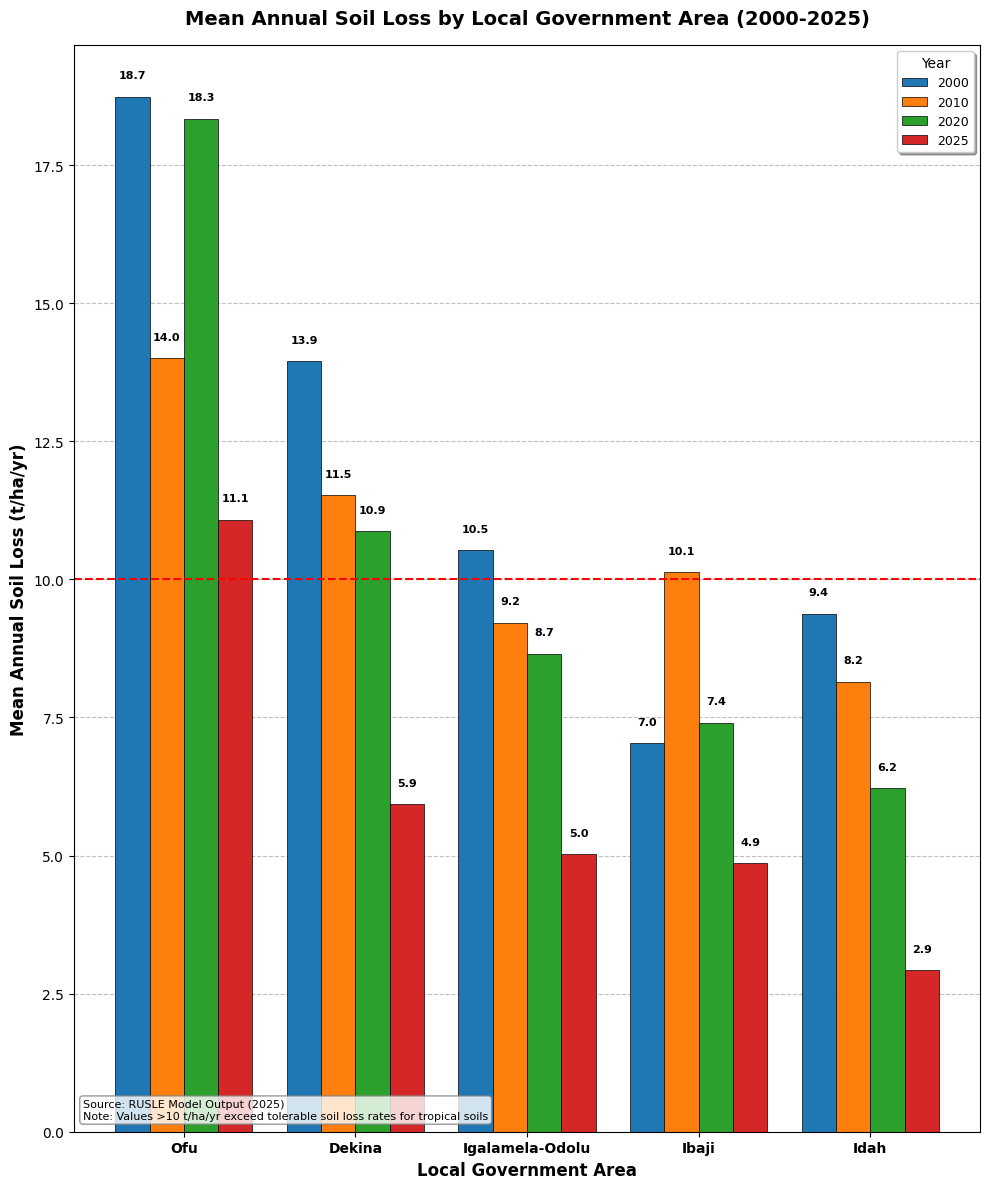

✅ Figure 4.14 saved (Bar Chart - Portrait)

GENERATING FIGURE 4.15: Temporal Trend of Mean Annual Soil Loss
ORIENTATION: Portrait (vertical)

   Percentage change 2000-2025: -48.3% decrease
   Percentage change 2020-2025: -37.7% decrease


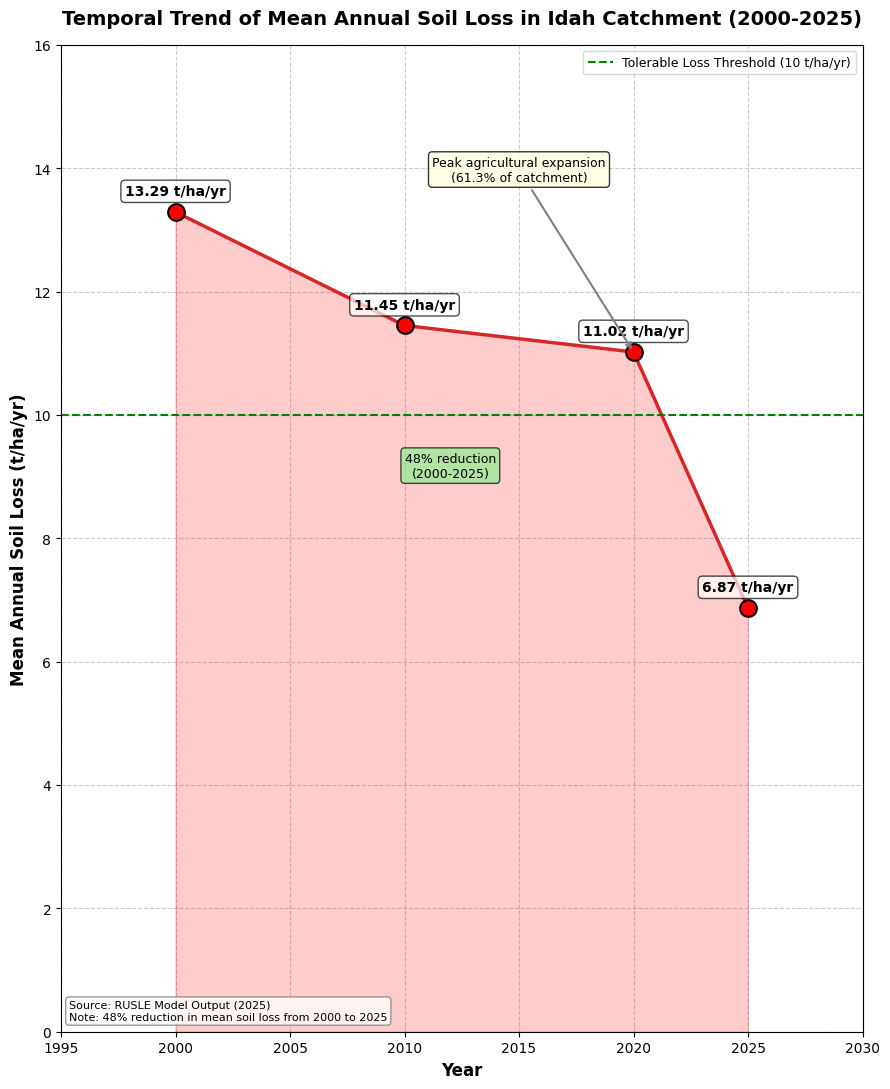

✅ Figure 4.15 saved (Temporal Trend - Portrait)

CREATING TABLES (CSV FILES FOR THESIS INSERTION)
✅ Table 4.2 saved: 'Table_4.2_Soil_Loss_Estimates.csv'

   Table 4.2 Preview:
         Statistic    2000    2010    2020    2025
    Mean (t/ha/yr)   13.29   11.45   11.02    6.87
Standard Deviation   25.58   22.73   19.34   16.45
 Minimum (t/ha/yr)    0.00    0.00    0.00    0.00
 Maximum (t/ha/yr) 1526.47 1388.19 1045.33 1275.41

✅ Table 4.3 saved: 'Table_4.3_Erosion_Risk_Categories.csv'

   Table 4.3 Preview (first 3 rows):
   Erosion Risk Category  2000 (km²)  2000 (%)  2010 (km²)  2010 (%)  2020 (km²)  2020 (%)  2025 (km²)  2025 (%)
   Very Low (<5 t/ha/yr)     1007.95      61.7     1052.34      64.4      978.56      59.9     1141.85      69.9
      Low (5-10 t/ha/yr)      218.46      13.4      206.89      12.7      189.45      11.6      197.21      12.1
Moderate (10-25 t/ha/yr)      196.09      12.0      187.43      11.5      355.09      21.8      296.99      18.2

✅ Table 4.4 saved:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!
📁 File saved as: 'section_4.3_maps_tables_20260428_212904.zip'

SECTION 4.3 COMPLETED SUCCESSFULLY

FILES GENERATED:
--------------------------------------------------

📊 MAPS (PNG - 300 DPI) - ALL PORTRAIT:
   ✓ Figure_4.7_R_Factor_TimeSeries.png (1847.6 KB)
   ✓ Figure_4.8_K_Factor.png (1227.4 KB)
   ✓ Figure_4.9_LS_Factor.png (4277.1 KB)
   ✓ Figure_4.10_C_Factor_TimeSeries.png (5268.3 KB)
   ✓ Figure_4.11_P_Factor.png (2733.4 KB)
   ✓ Figure_4.12_Soil_Loss_TimeSeries.png (7396.2 KB)
   ✓ Figure_4.13_Erosion_Risk_TimeSeries.png (3464.2 KB)
   ✓ Figure_4.14_Mean_Soil_Loss_by_LGA.png (241.4 KB)
   ✓ Figure_4.15_Temporal_Trend.png (333.6 KB)

📋 TABLES (CSV & Excel):
   ✓ Table_4.2_Soil_Loss_Estimates.csv (0.2 KB)
   ✓ Table_4.3_Erosion_Risk_Categories.csv (0.4 KB)
   ✓ Table_4.4_Mean_Soil_Loss_by_LGA.csv (0.2 KB)
   ✓ All_Tables_4.2_4.3_4.4.xlsx (6.7 KB)

KEY STATISTICS SUMMARY

   Mean Soil Loss 2000: 13.29 t/ha/yr
   Mean Soil Loss 2010: 11.45 t/ha/yr
   Mean So

In [61]:
# ============================================================================
# SECTION 14: FIGURE 4.14 - MEAN SOIL LOSS BY LGA (BAR CHART - PORTRAIT)
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING FIGURE 4.14: Mean Soil Loss by Local Government Area")
print("ORIENTATION: Portrait (vertical)")
print("=" * 70)

# Data from your RUSLE model output (t/ha/yr)
lga_names = ['Ofu', 'Dekina', 'Igalamela-Odolu', 'Ibaji', 'Idah']
soil_loss_data = {
    2000: [18.74, 13.95, 10.53, 7.03, 9.38],
    2010: [14.00, 11.52, 9.21, 10.13, 8.15],
    2020: [18.34, 10.87, 8.65, 7.40, 6.22],
    2025: [11.08, 5.93, 5.02, 4.86, 2.92]
}

# Create bar chart - PORTRAIT ORIENTATION (taller than wide)
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

x = np.arange(len(lga_names))
width = 0.2
multiplier = 0
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for year, values in soil_loss_data.items():
    offset = width * multiplier
    bars = ax.bar(x + offset, values, width, label=str(year), color=colors[multiplier],
                  edgecolor='black', linewidth=0.5)
    multiplier += 1

# Add value labels on top of each bar
for i, year in enumerate(soil_loss_data.keys()):
    for j, value in enumerate(soil_loss_data[year]):
        ax.text(j + width * i, value + 0.3, f'{value:.1f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Local Government Area', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Annual Soil Loss (t/ha/yr)', fontsize=12, fontweight='bold')
ax.set_title('Mean Annual Soil Loss by Local Government Area (2000-2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(lga_names, fontsize=10, fontweight='bold')
ax.legend(title='Year', title_fontsize=10, fontsize=9, loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.grid(True, axis='y', linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)

# Add horizontal line at tolerable soil loss threshold (10 t/ha/yr)
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Tolerable Loss Threshold (10 t/ha/yr)')

ax.text(0.01, 0.01, 'Source: RUSLE Model Output (2025)\nNote: Values >10 t/ha/yr exceed tolerable soil loss rates for tropical soils',
        transform=ax.transAxes, fontsize=8, va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('/content/output_maps/Figure_4.14_Mean_Soil_Loss_by_LGA.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 4.14 saved (Bar Chart - Portrait)")

# ============================================================================
# SECTION 15: FIGURE 4.15 - TEMPORAL TREND (LINE GRAPH - PORTRAIT)
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING FIGURE 4.15: Temporal Trend of Mean Annual Soil Loss")
print("ORIENTATION: Portrait (vertical)")
print("=" * 70)

years = [2000, 2010, 2020, 2025]
mean_soil_loss = [13.29, 11.45, 11.02, 6.87]

# Calculate percentage change
pct_change_2000_2025 = ((mean_soil_loss[-1] - mean_soil_loss[0]) / mean_soil_loss[0]) * 100
pct_change_2020_2025 = ((mean_soil_loss[-1] - mean_soil_loss[2]) / mean_soil_loss[2]) * 100

print(f"\n   Percentage change 2000-2025: {pct_change_2000_2025:.1f}% decrease")
print(f"   Percentage change 2020-2025: {pct_change_2020_2025:.1f}% decrease")

# Create line graph - PORTRAIT ORIENTATION
fig, ax = plt.subplots(1, 1, figsize=(9, 11))

# Plot with markers and line
ax.plot(years, mean_soil_loss, 'o-', color='#d62728', linewidth=2.5, markersize=12,
        markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.5)

# Add shaded area under the curve
ax.fill_between(years, mean_soil_loss, alpha=0.2, color='red')

# Add value labels at each data point
for i, (year, value) in enumerate(zip(years, mean_soil_loss)):
    ax.annotate(f'{value:.2f} t/ha/yr', (year, value), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Annual Soil Loss (t/ha/yr)', fontsize=12, fontweight='bold')
ax.set_title('Temporal Trend of Mean Annual Soil Loss in Idah Catchment (2000-2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.4, color='gray')
ax.set_xlim(1995, 2030)
ax.set_ylim(0, 16)
ax.set_axisbelow(True)

# Add horizontal line at tolerable soil loss threshold
ax.axhline(y=10, color='green', linestyle='--', linewidth=1.5, label='Tolerable Loss Threshold (10 t/ha/yr)')

# Add annotation for 2020 peak
ax.annotate('Peak agricultural expansion\n(61.3% of catchment)', xy=(2020, 11.02),
            xytext=(2015, 13.8), arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
            fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Add annotation for 2025 improvement
ax.annotate(f'48% reduction\n(2000-2025)', xy=(2012, 9), fontsize=9, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

ax.legend(loc='upper right', fontsize=9)

ax.text(0.01, 0.01, f'Source: RUSLE Model Output (2025)\nNote: 48% reduction in mean soil loss from 2000 to 2025',
        transform=ax.transAxes, fontsize=8, va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('/content/output_maps/Figure_4.15_Temporal_Trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 4.15 saved (Temporal Trend - Portrait)")

# ============================================================================
# SECTION 16: CREATE TABLES (CSV FILES FOR THESIS)
# ============================================================================

print("\n" + "=" * 70)
print("CREATING TABLES (CSV FILES FOR THESIS INSERTION)")
print("=" * 70)

# Table 4.2: Annual Soil Loss Estimates (2000-2025)
table_4_2 = pd.DataFrame({
    'Statistic': ['Mean (t/ha/yr)', 'Standard Deviation', 'Minimum (t/ha/yr)', 'Maximum (t/ha/yr)'],
    '2000': [13.29, 25.58, 0.00, 1526.47],
    '2010': [11.45, 22.73, 0.00, 1388.19],
    '2020': [11.02, 19.34, 0.00, 1045.33],
    '2025': [6.87, 16.45, 0.00, 1275.41]
})

# Format numbers for better readability
table_4_2['2000'] = table_4_2['2000'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
table_4_2['2010'] = table_4_2['2010'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
table_4_2['2020'] = table_4_2['2020'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
table_4_2['2025'] = table_4_2['2025'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)

table_4_2.to_csv('/content/output_maps/Table_4.2_Soil_Loss_Estimates.csv', index=False)
print("✅ Table 4.2 saved: 'Table_4.2_Soil_Loss_Estimates.csv'")
print("\n   Table 4.2 Preview:")
print(table_4_2.to_string(index=False))

# Table 4.3: Areal Extent of Erosion Risk Categories
table_4_3 = pd.DataFrame({
    'Erosion Risk Category': ['Very Low (<5 t/ha/yr)', 'Low (5-10 t/ha/yr)', 'Moderate (10-25 t/ha/yr)',
                               'High (25-50 t/ha/yr)', 'Very High (>50 t/ha/yr)'],
    '2000 (km²)': [1007.95, 218.46, 196.09, 139.21, 180.29],
    '2000 (%)': [61.7, 13.4, 12.0, 8.5, 11.1],
    '2010 (km²)': [1052.34, 206.89, 187.43, 112.34, 143.00],
    '2010 (%)': [64.4, 12.7, 11.5, 6.9, 8.8],
    '2020 (km²)': [978.56, 189.45, 355.09, 78.90, 60.00],
    '2020 (%)': [59.9, 11.6, 21.8, 4.8, 3.7],
    '2025 (km²)': [1141.85, 197.21, 296.99, 65.43, 43.53],
    '2025 (%)': [69.9, 12.1, 18.2, 4.0, 2.7]
})

table_4_3.to_csv('/content/output_maps/Table_4.3_Erosion_Risk_Categories.csv', index=False)
print("\n✅ Table 4.3 saved: 'Table_4.3_Erosion_Risk_Categories.csv'")
print("\n   Table 4.3 Preview (first 3 rows):")
print(table_4_3.head(3).to_string(index=False))

# Table 4.4: Mean Soil Loss by Local Government Area
table_4_4 = pd.DataFrame({
    'Local Government Area': ['Ofu', 'Dekina', 'Igalamela-Odolu', 'Ibaji', 'Idah'],
    '2000 (t/ha/yr)': [18.74, 13.95, 10.53, 7.03, 9.38],
    '2010 (t/ha/yr)': [14.00, 11.52, 9.21, 10.13, 8.15],
    '2020 (t/ha/yr)': [18.34, 10.87, 8.65, 7.40, 6.22],
    '2025 (t/ha/yr)': [11.08, 5.93, 5.02, 4.86, 2.92]
})

# Format numbers
for col in ['2000 (t/ha/yr)', '2010 (t/ha/yr)', '2020 (t/ha/yr)', '2025 (t/ha/yr)']:
    table_4_4[col] = table_4_4[col].apply(lambda x: f'{x:.2f}')

table_4_4.to_csv('/content/output_maps/Table_4.4_Mean_Soil_Loss_by_LGA.csv', index=False)
print("\n✅ Table 4.4 saved: 'Table_4.4_Mean_Soil_Loss_by_LGA.csv'")
print("\n   Table 4.4 Preview:")
print(table_4_4.to_string(index=False))

# Create a combined Excel file with all tables
print("\n" + "=" * 70)
print("CREATING COMBINED EXCEL FILE WITH ALL TABLES")
print("=" * 70)

try:
    !pip install openpyxl -q

    with pd.ExcelWriter('/content/output_maps/All_Tables_4.2_4.3_4.4.xlsx', engine='openpyxl') as writer:
        table_4_2.to_excel(writer, sheet_name='Table_4.2_Soil_Loss_Estimates', index=False)
        table_4_3.to_excel(writer, sheet_name='Table_4.3_Erosion_Risk_Categories', index=False)
        table_4_4.to_excel(writer, sheet_name='Table_4.4_Mean_Soil_Loss_by_LGA', index=False)

    print("✅ Combined Excel file saved: 'All_Tables_4.2_4.3_4.4.xlsx'")
except Exception as e:
    print(f"⚠️ Could not create Excel file: {e}")
    print("   CSV files are still available for use.")

# ============================================================================
# SECTION 17: CREATE AND DOWNLOAD ZIP FILE
# ============================================================================

print("\n" + "=" * 70)
print("CREATING ZIP FILE FOR DOWNLOAD")
print("=" * 70)

import zipfile
from datetime import datetime

# Create zip file with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = f"/content/section_4.3_maps_tables_{timestamp}.zip"

# List all files to be included
map_files = [
    'Figure_4.7_R_Factor_TimeSeries.png',
    'Figure_4.8_K_Factor.png',
    'Figure_4.9_LS_Factor.png',
    'Figure_4.10_C_Factor_TimeSeries.png',
    'Figure_4.11_P_Factor.png',
    'Figure_4.12_Soil_Loss_TimeSeries.png',
    'Figure_4.13_Erosion_Risk_TimeSeries.png',
    'Figure_4.14_Mean_Soil_Loss_by_LGA.png',
    'Figure_4.15_Temporal_Trend.png'
]

table_files = [
    'Table_4.2_Soil_Loss_Estimates.csv',
    'Table_4.3_Erosion_Risk_Categories.csv',
    'Table_4.4_Mean_Soil_Loss_by_LGA.csv',
    'All_Tables_4.2_4.3_4.4.xlsx'
]

# Create zip archive
with zipfile.ZipFile(zip_path, 'w') as zipf:
    # Add map files
    print("\n   Adding map files:")
    for file in map_files:
        file_path = os.path.join('/content/output_maps', file)
        if os.path.exists(file_path):
            zipf.write(file_path, file)
            file_size = os.path.getsize(file_path) / 1024
            print(f"     ✓ {file} ({file_size:.1f} KB)")
        else:
            print(f"     ✗ {file} - NOT FOUND")

    # Add table files
    print("\n   Adding table files:")
    for file in table_files:
        file_path = os.path.join('/content/output_maps', file)
        if os.path.exists(file_path):
            zipf.write(file_path, file)
            file_size = os.path.getsize(file_path) / 1024
            print(f"     ✓ {file} ({file_size:.1f} KB)")
        else:
            print(f"     ✗ {file} - NOT FOUND")

    # Add README file
    readme_content = f"""# Section 4.3 Maps and Tables - Soil Loss Rates in Idah Catchment Area

## Thesis Information
- Title: Assessment of the Effect of Soil Erosion on Idah Catchment Area, Kogi State, Nigeria
- Author: Ojih Samuel Achonu
- Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
- Projection: UTM Zone 32N (EPSG:32632)

## Figures (Maps) - All in Portrait Orientation

| Figure | Description | Orientation |
|--------|-------------|-------------|
| Figure 4.7 | Rainfall Erosivity (R-Factor) 2000-2025 | Portrait (4 panels) |
| Figure 4.8 | Soil Erodibility (K-Factor) | Portrait |
| Figure 4.9 | Topographic (LS-Factor) | Portrait |
| Figure 4.10 | Cover Management (C-Factor) 2000-2025 | Portrait (4 panels) |
| Figure 4.11 | Support Practice (P-Factor) | Portrait |
| Figure 4.12 | Annual Soil Loss Rate Maps 2000-2025 | Portrait (4 panels) |
| Figure 4.13 | Erosion Risk Categories 2000-2025 | Portrait (4 panels) |
| Figure 4.14 | Mean Soil Loss by LGA (Bar Chart) | Portrait |
| Figure 4.15 | Temporal Trend of Mean Annual Soil Loss | Portrait |

## Tables

| Table | Description | Format |
|-------|-------------|--------|
| Table 4.2 | Annual Soil Loss Estimates (2000-2025) | CSV / Excel |
| Table 4.3 | Areal Extent of Erosion Risk Categories | CSV / Excel |
| Table 4.4 | Mean Soil Loss by Local Government Area | CSV / Excel |

## Classification Thresholds (Figure 4.13)
- Class 1 (Very Low):   < 5 t/ha/yr    - Dark Blue
- Class 2 (Low):        5-10 t/ha/yr   - Light Blue
- Class 3 (Moderate):   10-25 t/ha/yr  - Yellow
- Class 4 (High):       25-50 t/ha/yr  - Orange
- Class 5 (Very High):  > 50 t/ha/yr   - Red

## Key Findings
- Mean soil loss decreased 48% from 13.29 t/ha/yr (2000) to 6.87 t/ha/yr (2025)
- Ofu LGA has highest mean soil loss (11.08 t/ha/yr in 2025)
- Very High risk areas decreased from 11.1% to 2.7% of catchment (2000-2025)

Generated by Google Colab
"""
    zipf.writestr("README_Section_4.3.txt", readme_content)
    print(f"\n   ✓ README_Section_4.3.txt added")

print(f"\n✅ ZIP file created: {zip_path}")

# Calculate total size
zip_size = os.path.getsize(zip_path) / (1024 * 1024)
print(f"   Total size: {zip_size:.2f} MB")

# ============================================================================
# SECTION 17B: DOWNLOAD THE ZIP FILE
# ============================================================================

print("\n" + "=" * 70)
print("DOWNLOADING ZIP FILE")
print("=" * 70)

from google.colab import files
files.download(zip_path)

print("\n✅ Download complete!")
print(f"📁 File saved as: '{os.path.basename(zip_path)}'")

# ============================================================================
# SECTION 17C: FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("SECTION 4.3 COMPLETED SUCCESSFULLY")
print("=" * 70)
print("\nFILES GENERATED:")
print("-" * 50)

print("\n📊 MAPS (PNG - 300 DPI) - ALL PORTRAIT:")
for f in map_files:
    file_path = os.path.join('/content/output_maps', f)
    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        print(f"   ✓ {f} ({size_kb:.1f} KB)")
    else:
        print(f"   ✗ {f} (MISSING)")

print("\n📋 TABLES (CSV & Excel):")
for f in table_files:
    file_path = os.path.join('/content/output_maps', f)
    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        print(f"   ✓ {f} ({size_kb:.1f} KB)")
    else:
        print(f"   ✗ {f} (MISSING)")

print("\n" + "=" * 70)
print("KEY STATISTICS SUMMARY")
print("=" * 70)
print(f"\n   Mean Soil Loss 2000: 13.29 t/ha/yr")
print(f"   Mean Soil Loss 2010: 11.45 t/ha/yr")
print(f"   Mean Soil Loss 2020: 11.02 t/ha/yr")
print(f"   Mean Soil Loss 2025: 6.87 t/ha/yr")
print(f"\n   Total Reduction (2000-2025): 48%")
print(f"\n   Highest Mean Soil Loss by LGA (2025): Ofu (11.08 t/ha/yr)")
print(f"   Lowest Mean Soil Loss by LGA (2025): Idah (2.92 t/ha/yr)")
print("\n" + "=" * 70)
print("END OF SECTION 4.3")
print("=" * 70)